In [259]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from talib import stream

from collections import deque, defaultdict, Counter

import re
import tempfile
import gdown
import os

**Загрузка и обработка данных**

In [260]:
class KlinesDataLoader:
    """Загрузка данных OHLCV для symbols c Google Disk"""

    def __init__(self, symbols=None):
        if symbols is None:
            raise ValueError("Передайте название активов")

        if isinstance(symbols, str):
            symbols_list = [symbols]
        else:
            symbols_list = symbols

        self.symbols = symbols_list

    def statistics_df(self, dataframe):
        """Вывод статистики по датафрейму."""
        if dataframe is None or dataframe.empty:
            raise ValueError("Передан пустой DataFrame")

        print(f"Количество строк: {dataframe.shape[0]}\nКоличество столбцов: {dataframe.shape[1]}")
        print(f"Количество пропущенных значений: {dataframe.isna().sum().sum()}\n")
        print(f"Название столбцов: {', '.join(dataframe.columns.to_list())}")
        print(f"Название активов: {', '.join(self.symbols)}\n")
        for sym in self.symbols:
            print(f"Длина временного ряда актива {sym}: {dataframe[dataframe['symbol'] == sym].shape[0]}")
        print(f"\nВременные рамки ряда каждого актива:")
        for sym, ts in dataframe.groupby('symbol')['timestamp'].agg(['min', 'max']).iterrows():
            print(f"{sym}: {ts['min']} - {ts['max']}")

    def load_data(self, download_path, analyse_data=False, cleaning=False):
        '''
        Загрузка данных OHLCV с Google Drive.

        :param download_path: (str) ссылка на файл Google Drive.
        :param analyse_data: (bool) вывод статистики.
        :param cleaning: (bool) выравнивание временных рядов и удаление 'turnover'.
        :return: df: (DataFrame) отфильтрованный датафрейм.
        '''
        if not isinstance(download_path, str) or not download_path.strip():
            raise ValueError(
                "download_path должен быть непустой строкой со ссылкой на Google Drive"
            )

        match_id = re.search(r'/d/([a-zA-Z0-9_-]+)', download_path)
        if not match_id:
            raise ValueError(
                f"Не удалось извлечь file_id из ссылки: {download_path}"
            )
        file_id = match_id.group(1)

        url = f"https://drive.google.com/uc?id={file_id}"

        with tempfile.TemporaryDirectory() as tmp_dir:
            tmp_path = os.path.join(tmp_dir, "data.parquet")
            try:
                gdown.download(url, tmp_path, quiet=False)
            except Exception as e:
                raise ValueError(f"Не удалось найти файл с id: {file_id}") from e

            df = pd.read_parquet(tmp_path, engine='fastparquet')

        df = df[df['symbol'].isin(self.symbols)].reset_index(drop=True)

        if df.empty:
            raise ValueError(
                "После фильтрации по symbols датафрейм оказался пустым"
            )

        if analyse_data:
            print('\n\n\n\t\t\tСтатистика без фильтрации')
            self.statistics_df(df)

        if cleaning:
            minimal_ts_for_alignment = (
                df.groupby('symbol')['timestamp'].min().max()
            )
            df = df[df['timestamp'] >= minimal_ts_for_alignment]

            if 'turnover' in df.columns:
                df = df.drop(columns=['turnover'])

            df = df.reset_index(drop=True)

            if analyse_data:
                print(
                    '\n\n\t\t\tСтатистика после фильтрации (удаление столбца \'turnover\' и выравнивание временных рядов по активам)')
                self.statistics_df(df)

        display(df)

        return df

In [261]:
ALL_SYMBOLS = ['BTCUSDT', 'DOGEUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT']

DATA_PATH = "https://drive.google.com/file/d/1_1kFX2iAiXL3rmPDfLAMWydHJi_qWHo6/view?usp=sharing"

HISTORICAL_WINDOW_SIZE = 100 # минимальный размер окна данных OHLCV для расчёта индикаторов без np.nan

loader = KlinesDataLoader(symbols=ALL_SYMBOLS)

ohlcv_data = loader.load_data(download_path=DATA_PATH, analyse_data=True, cleaning=True)

Downloading...
From: https://drive.google.com/uc?id=1_1kFX2iAiXL3rmPDfLAMWydHJi_qWHo6
To: C:\Users\trosh\AppData\Local\Temp\tmpi6i83hf5\data.parquet
100%|██████████| 2.83M/2.83M [00:00<00:00, 3.56MB/s]





			Статистика без фильтрации
Количество строк: 50112
Количество столбцов: 8
Количество пропущенных значений: 0

Название столбцов: timestamp, open, high, low, close, volume, turnover, symbol
Название активов: BTCUSDT, DOGEUSDT, ETHUSDT, SOLUSDT, XRPUSDT

Длина временного ряда актива BTCUSDT: 10237
Длина временного ряда актива DOGEUSDT: 9897
Длина временного ряда актива ETHUSDT: 10237
Длина временного ряда актива SOLUSDT: 9591
Длина временного ряда актива XRPUSDT: 10150

Временные рамки ряда каждого актива:
BTCUSDT: 2021-07-05 12:00:00+00:00 - 2026-03-07 12:00:00+00:00
DOGEUSDT: 2021-08-31 04:00:00+00:00 - 2026-03-07 12:00:00+00:00
ETHUSDT: 2021-07-05 12:00:00+00:00 - 2026-03-07 12:00:00+00:00
SOLUSDT: 2021-10-21 04:00:00+00:00 - 2026-03-07 12:00:00+00:00
XRPUSDT: 2021-07-20 00:00:00+00:00 - 2026-03-07 12:00:00+00:00


			Статистика после фильтрации (удаление столбца 'turnover' и выравнивание временных рядов по активам)
Количество строк: 47955
Количество столбцов: 7
Количество пропущ

,timestamp,open,high,low,close,volume,symbol
0,2021-10-21 04:00:00+00:00,65070.8500,65247.1800,64176.5000,65125.2500,1.321231e+02,BTCUSDT
1,2021-10-21 08:00:00+00:00,65125.2500,66645.3900,64259.2700,64852.1900,1.755240e+02,BTCUSDT
2,2021-10-21 12:00:00+00:00,64852.1900,65622.6900,62128.5300,63029.4700,2.263843e+02,BTCUSDT
3,2021-10-21 16:00:00+00:00,63029.4700,63659.5600,62463.6400,62828.3600,1.540196e+02,BTCUSDT
4,2021-10-21 20:00:00+00:00,62828.3600,63103.9900,62077.0000,62228.4300,1.508869e+02,BTCUSDT
...,...,...,...,...,...,...,...
47950,2026-03-06 20:00:00+00:00,1.3631,1.3718,1.3542,1.3634,3.179297e+06,XRPUSDT
47951,2026-03-07 00:00:00+00:00,1.3634,1.3749,1.3625,1.3662,1.403948e+06,XRPUSDT
47952,2026-03-07 04:00:00+00:00,1.3662,1.3685,1.3608,1.3671,2.075217e+06,XRPUSDT
47953,2026-03-07 08:00:00+00:00,1.3671,1.3736,1.3630,1.3698,1.968777e+06,XRPUSDT


In [262]:
ohlcv_data['future_close_price'] = ohlcv_data.groupby('symbol')['close'].shift(-1)

ohlcv_data = ohlcv_data.dropna()

meta_cols = ohlcv_data.columns.to_list()

display(ohlcv_data)
print(f"Мета-колонки: {meta_cols}")

,timestamp,open,high,low,close,volume,symbol,future_close_price
0,2021-10-21 04:00:00+00:00,65070.8500,65247.1800,64176.5000,65125.2500,1.321231e+02,BTCUSDT,64852.1900
1,2021-10-21 08:00:00+00:00,65125.2500,66645.3900,64259.2700,64852.1900,1.755240e+02,BTCUSDT,63029.4700
2,2021-10-21 12:00:00+00:00,64852.1900,65622.6900,62128.5300,63029.4700,2.263843e+02,BTCUSDT,62828.3600
3,2021-10-21 16:00:00+00:00,63029.4700,63659.5600,62463.6400,62828.3600,1.540196e+02,BTCUSDT,62228.4300
4,2021-10-21 20:00:00+00:00,62828.3600,63103.9900,62077.0000,62228.4300,1.508869e+02,BTCUSDT,63215.3500
...,...,...,...,...,...,...,...,...
47949,2026-03-06 16:00:00+00:00,1.3564,1.3659,1.3457,1.3631,1.199268e+07,XRPUSDT,1.3634
47950,2026-03-06 20:00:00+00:00,1.3631,1.3718,1.3542,1.3634,3.179297e+06,XRPUSDT,1.3662
47951,2026-03-07 00:00:00+00:00,1.3634,1.3749,1.3625,1.3662,1.403948e+06,XRPUSDT,1.3671
47952,2026-03-07 04:00:00+00:00,1.3662,1.3685,1.3608,1.3671,2.075217e+06,XRPUSDT,1.3698


Мета-колонки: ['timestamp', 'open', 'high', 'low', 'close', 'volume', 'symbol', 'future_close_price']


In [263]:
train_period_start = pd.to_datetime('2022-05-06 00:00:00+00:00')
val_period_start = pd.to_datetime('2025-07-01 00:00:00+00:00')
test_period_start = pd.to_datetime('2026-01-01 00:00:00+00:00')

train_df = ohlcv_data[ohlcv_data['timestamp'] < val_period_start]
val_df = ohlcv_data[(ohlcv_data['timestamp'] >= val_period_start) & (ohlcv_data['timestamp'] < test_period_start)]
test_df = ohlcv_data[ohlcv_data['timestamp'] >= test_period_start]

print(f"Размерность начального датафрейма: {ohlcv_data.shape[0]}")
print(f"Размерность train_df: {train_df.shape[0]}")
print(f"Размерность val_df: {val_df.shape[0]}")
print(f"Размерность test_df: {test_df.shape[0]}")

if (train_df.shape[0] + val_df.shape[0] + test_df.shape[0]) == ohlcv_data.shape[0] and len(set(ohlcv_data['timestamp'].to_list()))== len(set(train_df['timestamp'].to_list() + val_df['timestamp'].to_list() + test_df['timestamp'].to_list())):
    print("Разбиение выполнено правильно!")

Размерность начального датафрейма: 47950
Размерность train_df: 40465
Размерность val_df: 5520
Размерность test_df: 1965
Разбиение выполнено правильно!


**Пайплайн обработки данных**

In [264]:
def stream_TA_lib(
        df,
        meta_cols,
        indicators_name=None,
        filter_indicators_name=None,
        dist_ema_periods=None,
        momentum_indicators_periods=None,
        return_indicators_periods=None,
        volatility_indicators_periods=None,
        vol_ma_period=None,
        range_ma_period=None,
        compute_all_indicators=False
):
    '''
    Универсальная функция для расчёта технических индикаторов с использованием stream TA-Lib.

    :param df: (pd.DataFrame) исторические данные OHLCV по активу
    :param meta_cols: (List[str]) название мета-колонок: OHLCV + timestamp + symbol
    :param indicators_name: (List[str]) названия индикаторов для расчёта
    :param filter_indicators_name: (List[str]) полные названия индикаторов для фильтрации
    :param dist_ema_periods: (List[int]) периоды для dist_ema
    :param momentum_indicators_periods: (List[int]) периоды для MOM, ROC, ADX, RSI
    :param return_indicators_periods: (List[int]) периоды для log_ret
    :param volatility_indicators_periods: (List[int]) периоды для volatility
    :param vol_ma_period: (int) период для vol_ma
    :param range_ma_period: (int) период для range_ma
    :param compute_all_indicators: (bool) рассчитать все индикаторы
    :return results: (Dict) словарь с рассчитанными индикаторами
    '''

    indicators_name = indicators_name or []
    filter_indicators_name = filter_indicators_name
    dist_ema_periods = dist_ema_periods or []
    momentum_indicators_periods = momentum_indicators_periods or []
    return_indicators_periods = return_indicators_periods or []
    volatility_indicators_periods = volatility_indicators_periods or []
    vol_ma_period = vol_ma_period
    range_ma_period = range_ma_period

    available_indicators = {
        'ADX', 'MACD_hist', 'MOM', 'NATR', 'OBV', 'ROC', 'RSI',
        'bb_pos', 'bb_width', 'body', 'dist_ema', 'log_ret', 'range',
        'range_ma', 'vol_expansion', 'vol_ma', 'vol_ratio', 'volatility'
    }

    if compute_all_indicators:
        indicators_to_compute = available_indicators
        dist_ema_periods = dist_ema_periods or [7, 21, 100]
        momentum_indicators_periods = momentum_indicators_periods or [7, 21]
        return_indicators_periods = return_indicators_periods or [1, 6, 12, 24]
        volatility_indicators_periods = volatility_indicators_periods or [6, 24]
        vol_ma_period = vol_ma_period or 20
        range_ma_period = range_ma_period or 20
    else:
        if not indicators_name:
            raise ValueError("Передайте в функцию названия индикаторов")

        invalid = [i for i in indicators_name if i not in available_indicators]
        if invalid:
            raise ValueError(
                f"Переданы неправильные индикаторы: {', '.join(invalid)}"
            )

        indicators_to_compute = set(indicators_name)

    open_p = df['open'].astype(float).values
    high_p = df['high'].astype(float).values
    low_p = df['low'].astype(float).values
    close_p = df['close'].astype(float).values
    volume = df['volume'].astype(float).values

    close_series = df['close']
    volume_series = df['volume']
    high_series = df['high']
    low_series = df['low']

    results = {}
    for col in meta_cols:
        results[col] = df[col].iloc[-1]

    # ============== Overlap Studies ==============
    if 'dist_ema' in indicators_to_compute:
        if not dist_ema_periods:
            raise ValueError("Необходимо передать dist_ema_periods для индикатора dist_ema")
        for p in dist_ema_periods:
            ema = stream.EMA(close_p, timeperiod=p)
            results[f'dist_ema_{p}'] = (close_p[-1] - ema) / (ema + 1e-9)

    # ============== Momentum Indicators ==============
    if any(ind in indicators_to_compute for ind in ['MOM', 'ROC', 'ADX', 'RSI']):
        if not momentum_indicators_periods:
            raise ValueError(
                "Необходимо передать momentum_indicators_periods для индикаторов MOM, ROC, ADX, RSI "
            )
        for p in momentum_indicators_periods:
            if 'MOM' in indicators_to_compute:
                results[f'MOM_{p}'] = stream.MOM(close_p, timeperiod=p)
            if 'ROC' in indicators_to_compute:
                results[f'ROC_{p}'] = stream.ROC(close_p, timeperiod=p)
            if 'ADX' in indicators_to_compute:
                results[f'ADX_{p}'] = stream.ADX(
                    high_p, low_p, close_p, timeperiod=p
                )
            if 'RSI' in indicators_to_compute:
                results[f'RSI_{p}'] = stream.RSI(close_p, timeperiod=p)

    # ============== MACD ==============
    if 'MACD_hist' in indicators_to_compute:
        _, _, macd_hist = stream.MACD(
            close_p, fastperiod=12, slowperiod=26, signalperiod=9
        )
        results['MACD_hist'] = macd_hist

    # ============== Volatility ==============
    if 'NATR' in indicators_to_compute:
        results['NATR'] = stream.NATR(
            high_p, low_p, close_p, timeperiod=14
        )

    if 'bb_width' in indicators_to_compute or 'bb_pos' in indicators_to_compute:
        upper, middle, lower = stream.BBANDS(
            close_p, timeperiod=20, nbdevup=2, nbdevdn=2
        )
        if 'bb_width' in indicators_to_compute:
            results['bb_width'] = (upper - lower) / (middle + 1e-9)
        if 'bb_pos' in indicators_to_compute:
            results['bb_pos'] = (close_p[-1] - lower) / (upper - lower + 1e-9)

    # ============== Returns ==============
    if 'log_ret' in indicators_to_compute:
        if not return_indicators_periods:
            raise ValueError(
                "Необходимо передать return_indicators_periods для индикатора log_ret"
            )
        for p in return_indicators_periods:
            results[f'log_ret_{p}'] = np.log(
                close_series.iloc[-1] /
                close_series.iloc[-1 - p]
            )

    if 'volatility' in indicators_to_compute:
        if not volatility_indicators_periods:
            raise ValueError(
                "Необходимо передать volatility_indicators_periods для индикатора volatility"
            )
        log_ret1 = np.log(close_series / close_series.shift(1))
        for p in volatility_indicators_periods:
            results[f'volatility_{p}'] = log_ret1.iloc[-p:].std()

    # ============== Volume ==============
    if 'OBV' in indicators_to_compute:
        results['OBV'] = stream.OBV(close_p, volume)

    # if 'AD' in indicators_to_compute:
    #     results['AD'] = stream.AD(high_p, low_p, close_p, volume)

    if 'vol_ma' in indicators_to_compute or 'vol_ratio' in indicators_to_compute:
        if not vol_ma_period:
            raise ValueError("Необходимо передать vol_ma_period для индикаторов vol_ma, vol_ratio")

        vol_ma = volume_series.iloc[-vol_ma_period:].mean()

        if 'vol_ma' in indicators_to_compute:
            results[f'vol_ma{vol_ma_period}'] = vol_ma

        if 'vol_ratio' in indicators_to_compute:
            results['vol_ratio'] = volume[-1] / (vol_ma + 1e-9)

    # ============== Price Range Features ==============
    range_val = (high_p[-1] - low_p[-1]) / close_p[-1]
    range_series = (high_series - low_series) / close_series

    if 'range' in indicators_to_compute:
        results['range'] = range_val

    if 'body' in indicators_to_compute:
        results['body'] = abs(close_p[-1] - open_p[-1]) / close_p[-1]

    if 'range_ma' in indicators_to_compute or 'vol_expansion' in indicators_to_compute:
        if not range_ma_period:
            raise ValueError("Необходимо передать range_ma_period для индикаторов range_ma, vol_expansion ")

        range_ma = range_series.iloc[-range_ma_period:].mean()

        if 'range_ma' in indicators_to_compute:
            results[f'range_ma{range_ma_period}'] = range_ma

        if 'vol_expansion' in indicators_to_compute:
            results['vol_expansion'] = range_val / (range_ma + 1e-9)

    if filter_indicators_name is not None:
        for indicator_name in list(results.keys()):
            if indicator_name not in filter_indicators_name and indicator_name not in meta_cols:
                results.pop(indicator_name)

    return results

In [265]:
transform_dict = {
    'diff': ('OBV'),
    'bounded': 'RSI',
    'scaled': ('ADX'),
    'log1p': ('vol_ma', 'vol_ratio', 'vol_expansion'),
    'sqrt': ('bb_width', 'volatility', 'body', 'range', 'range_ma'),
    'norm': ('bb_pos'),
    'raw': ('MACD_hist', 'MOM', 'NATR', 'ROC', 'dist_ema', 'log_ret')
}


# NATR - относительный индикатор в процентах
# ADX - не осциллятор, а сила тренда
# RSI - осциллятор
# AD/OBV - накопительные объёмные индикаторы. Избавился от признака AD так как после трансформации diff он вырождается в константу.
# MOM/ROC - индикаторы импульса (ROC - "осциллятор, колеблющийся вокруг нулевой линии")
# dist_ema - относительное отклонение цены от EMA
# log_ret - логарифмическая доходность
# MACD_hist - импульс тренда
# bb_pos - позиция цены внутри полос Боллинджера (принимается значения от -0.5 до 1.5)
# bb_width - относительная ширина полос Боллинджера (принимает только положительные значения, имеет правый хвост)
# body - относительный размер тела свечи (имеет длинный правый хвост, много значений около нуля, принимает только положительные значения)
# range - относительный размер свечи (имеет длинный правый хвост)
# range_ma - средний относительный диапазон за N периодов. Базовая волатильность свечей (имеет правый хвост)
# vol_expansion - отношение текущего диапазона к среднему за 20 периодов. (имеет правый хвост)
# vol_ma - средний объём за последние N свечей
# vol_ratio - отношение текущего объёма к среднему за 20 периодов.
# volatility - стандартное отклонение логарифмических доходностей. Оценка краткосрочного риска. (имеет правый хвост)

def map_indicator_category(name):
    '''
    Сопоставляет колонку индикатора с методом трансформации
    '''
    if name.startswith('ADX'):
        return 'scaled'

    for key, prefixes in transform_dict.items():
        if name.startswith(prefixes):
            return key
    return None


def transform_online(df, meta_cols):
    '''
    Трансформирует признаки для нормализации

    :param df: (DataFrame) датафрейм с индикаторами
    :param meta_cols: (List[str]) название мета-колонок: OHLCV + timestamp + symbol
    :return: results: (Dict) словарь признаков с соответсвующими трансформациями
    '''
    if df.empty:
        raise ValueError(
            f"Передан пустой датафрейм"
        )

    results = {}
    for col in meta_cols:
        results[col] = df[col].iloc[-1]

    for col in df.columns:
        if col in meta_cols:
            continue

        cat = map_indicator_category(col)

        if cat is None:
            raise ValueError(
                f"Для индикатора {col} не было найдено подходящей трансформации"
            )

        x = float(df[col].iloc[-1])

        if cat == 'diff':
            if len(df) < 2:
                results[f"{col}_diff"] = 0
            else:
                prev_x = float(df[col].iloc[-2])
                if pd.isna(prev_x) or pd.isna(x):
                    results[f"{col}_diff"] = 0
                else:
                    results[f"{col}_diff"] = (x - prev_x) / (abs(prev_x) + 1e-9)

        elif cat == 'bounded':
            results[f"{col}_bounded"] = (x - 50) / 50

        elif cat == 'scaled':
            results[f"{col}_scaled"] = (x - 25) / 25

        elif cat == 'log1p':
            results[f"{col}_log1p"] = np.log1p(np.maximum(x, 0.0))

        elif cat == 'norm':
            results[f"{col}_norm"] = (x - 0.5) / 1.0  # [-1, 1]

        elif cat == 'raw':
            results[f"{col}"] = x

        elif cat == 'sqrt':
            results[f"{col}_sqrt"] = np.sqrt(max(x, 0.0))

        else:
            raise ValueError(
                f"Неожиданное поведение функции map_indicator_category. Вернувшаяся категория: {cat}"
            )

    return results

In [266]:
class rolling_z_score_clip_online():
    '''
    Собирает статистику и применять скользящую z-score нормализацию и клиппинг

    :param window: (int) устанавливает размер окна для z-score
    :param clip_value: (int) задаёт границы для симметричного клиппинга
    :param warmup: (bool) True - первые window-1 примеров будут получать np.nan и использоваться для сбора статистики
    :param std_history (bool) False - устанавливает флаг для сохранения истории std
    :return: out: (Dict) словарь признаков после rolling z-score
    '''

    def __init__(self, window=24, clip_value=5, warmup=True):
        self.window = window
        self.buffers = defaultdict(lambda: deque(maxlen=window))
        self.clip_value = clip_value
        self.threshold = self.window if warmup == True else 2

    def rolling_z_score_clip(self, results, meta_cols, symbol):
        if symbol not in ALL_SYMBOLS:
            raise ValueError(
                f"Актив {symbol} отсутствует. Список доступных активов: {ALL_SYMBOLS}"
            )

        forbidden_suffixes = ("_bounded", "_scaled", "_norm")  # Эти признаки НЕ стандартизируем

        out = {}

        for col, x in results.items():
            if col.endswith(forbidden_suffixes) or col in meta_cols:
                out[col] = results[col]
                continue
            self.buffers[(symbol, col)].append(x)

            if len(self.buffers[(symbol, col)]) < self.threshold:
                out[f'{col}_z'] = np.nan
                continue
            mean = np.array(self.buffers[(symbol, col)]).mean()
            std = np.array(self.buffers[(symbol, col)]).std(ddof=1)
            out[f'{col}_z'] = np.clip((x - mean) / std, -self.clip_value, self.clip_value)

        return out

    def reset_statistics_by_symbol(self, symbol):
        keys_to_delete = [key for key in self.buffers.keys() if key[0] == symbol]
        for key in keys_to_delete:
            del self.buffers[key]

**Графики распределений признаков**

In [267]:
def plot_feature_distributions(dataframe, symbol):
    '''
    Строит графики распределения по признакам для актива
    '''
    if symbol not in ALL_SYMBOLS:
        raise ValueError(
            f"Актив {symbol} отсутствует. Список доступных активов: {ALL_SYMBOLS}"
        )

    df_asset = dataframe[dataframe['symbol'] == symbol]

    columns = df_asset.columns.difference(meta_cols)

    if columns.empty:
        raise ValueError(
            f"В переданном датафрейме нет колонок признаков. Только мета-колонки."
        )

    num_cols = len(columns)
    cols_per_row = 5
    rows = (num_cols + cols_per_row - 1) // cols_per_row

    fig, axes = plt.subplots(rows, cols_per_row, figsize=(20, rows * 4), constrained_layout=True)
    axes = axes.flatten()

    for i, col in enumerate(columns):
        sns.histplot(data=df_asset, x=col, ax=axes[i])
        axes[i].set_title(col)
        axes[i].tick_params(axis='x', rotation=45)

    # Удаляем лишние пустые графики (если признаки закончились)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f"Графики распределений признаков для актива {symbol}", fontsize=16)
    plt.show()

In [268]:
# ['BTCUSDT', 'DOGEUSDT', 'ETHUSDT', 'SOLUSDT', 'XRPUSDT']
symbol = ALL_SYMBOLS[0]  # поменяйте индекс, чтобы посчитать индикаторы для другого актива
window_rolling_z_score = 18
standardisation_warmup_use = True

list_indicators_asset = []
df_asset = train_df[train_df['symbol'] == symbol]
rolling_z_score_standardization = rolling_z_score_clip_online(window=window_rolling_z_score, warmup=standardisation_warmup_use)

config_for_indicators = {
    'indicators_name': ['ADX', 'MOM', 'RSI', 'body', 'bb_width', 'dist_ema', 'log_ret', 'volatility'],
    'filter_indicators_name': None,
    'dist_ema_periods': [6, 18, 42, 100],
    'momentum_indicators_periods': [6, 18, 42],
    'return_indicators_periods': [1, 6, 18, 42],
    'volatility_indicators_periods': [6, 18, 42, 100],
    'vol_ma_period': 18,
    'range_ma_period': 18,
    'compute_all_indicators': True
}

for i in range(HISTORICAL_WINDOW_SIZE, len(df_asset) + 1):
    list_indicators_asset.append(
        stream_TA_lib(df_asset.iloc[i - HISTORICAL_WINDOW_SIZE:i], meta_cols=meta_cols, **config_for_indicators))

df_indicators_asset = pd.DataFrame(list_indicators_asset).reset_index(drop=True)  # датафрейм с индикаторами stream_TA_lib

list_transform_indicators_asset = []
list_z_score_indicators_asset = []
for i in range(1, len(df_indicators_asset) + 1):
    transform_indicators_result = transform_online(df_indicators_asset.iloc[:i], meta_cols=meta_cols)

    list_transform_indicators_asset.append(transform_indicators_result)
    list_z_score_indicators_asset.append(
        rolling_z_score_standardization.rolling_z_score_clip(transform_indicators_result, meta_cols=meta_cols, symbol=symbol))

df_transform_indicators_asset = pd.DataFrame(list_transform_indicators_asset).reset_index(drop=True)  # датафрейм с индикаторами после трансформации
df_z_score_indicators_asset = pd.DataFrame(list_z_score_indicators_asset).dropna().reset_index(drop=True)  # датафрейм с индикаторами после стандартизации

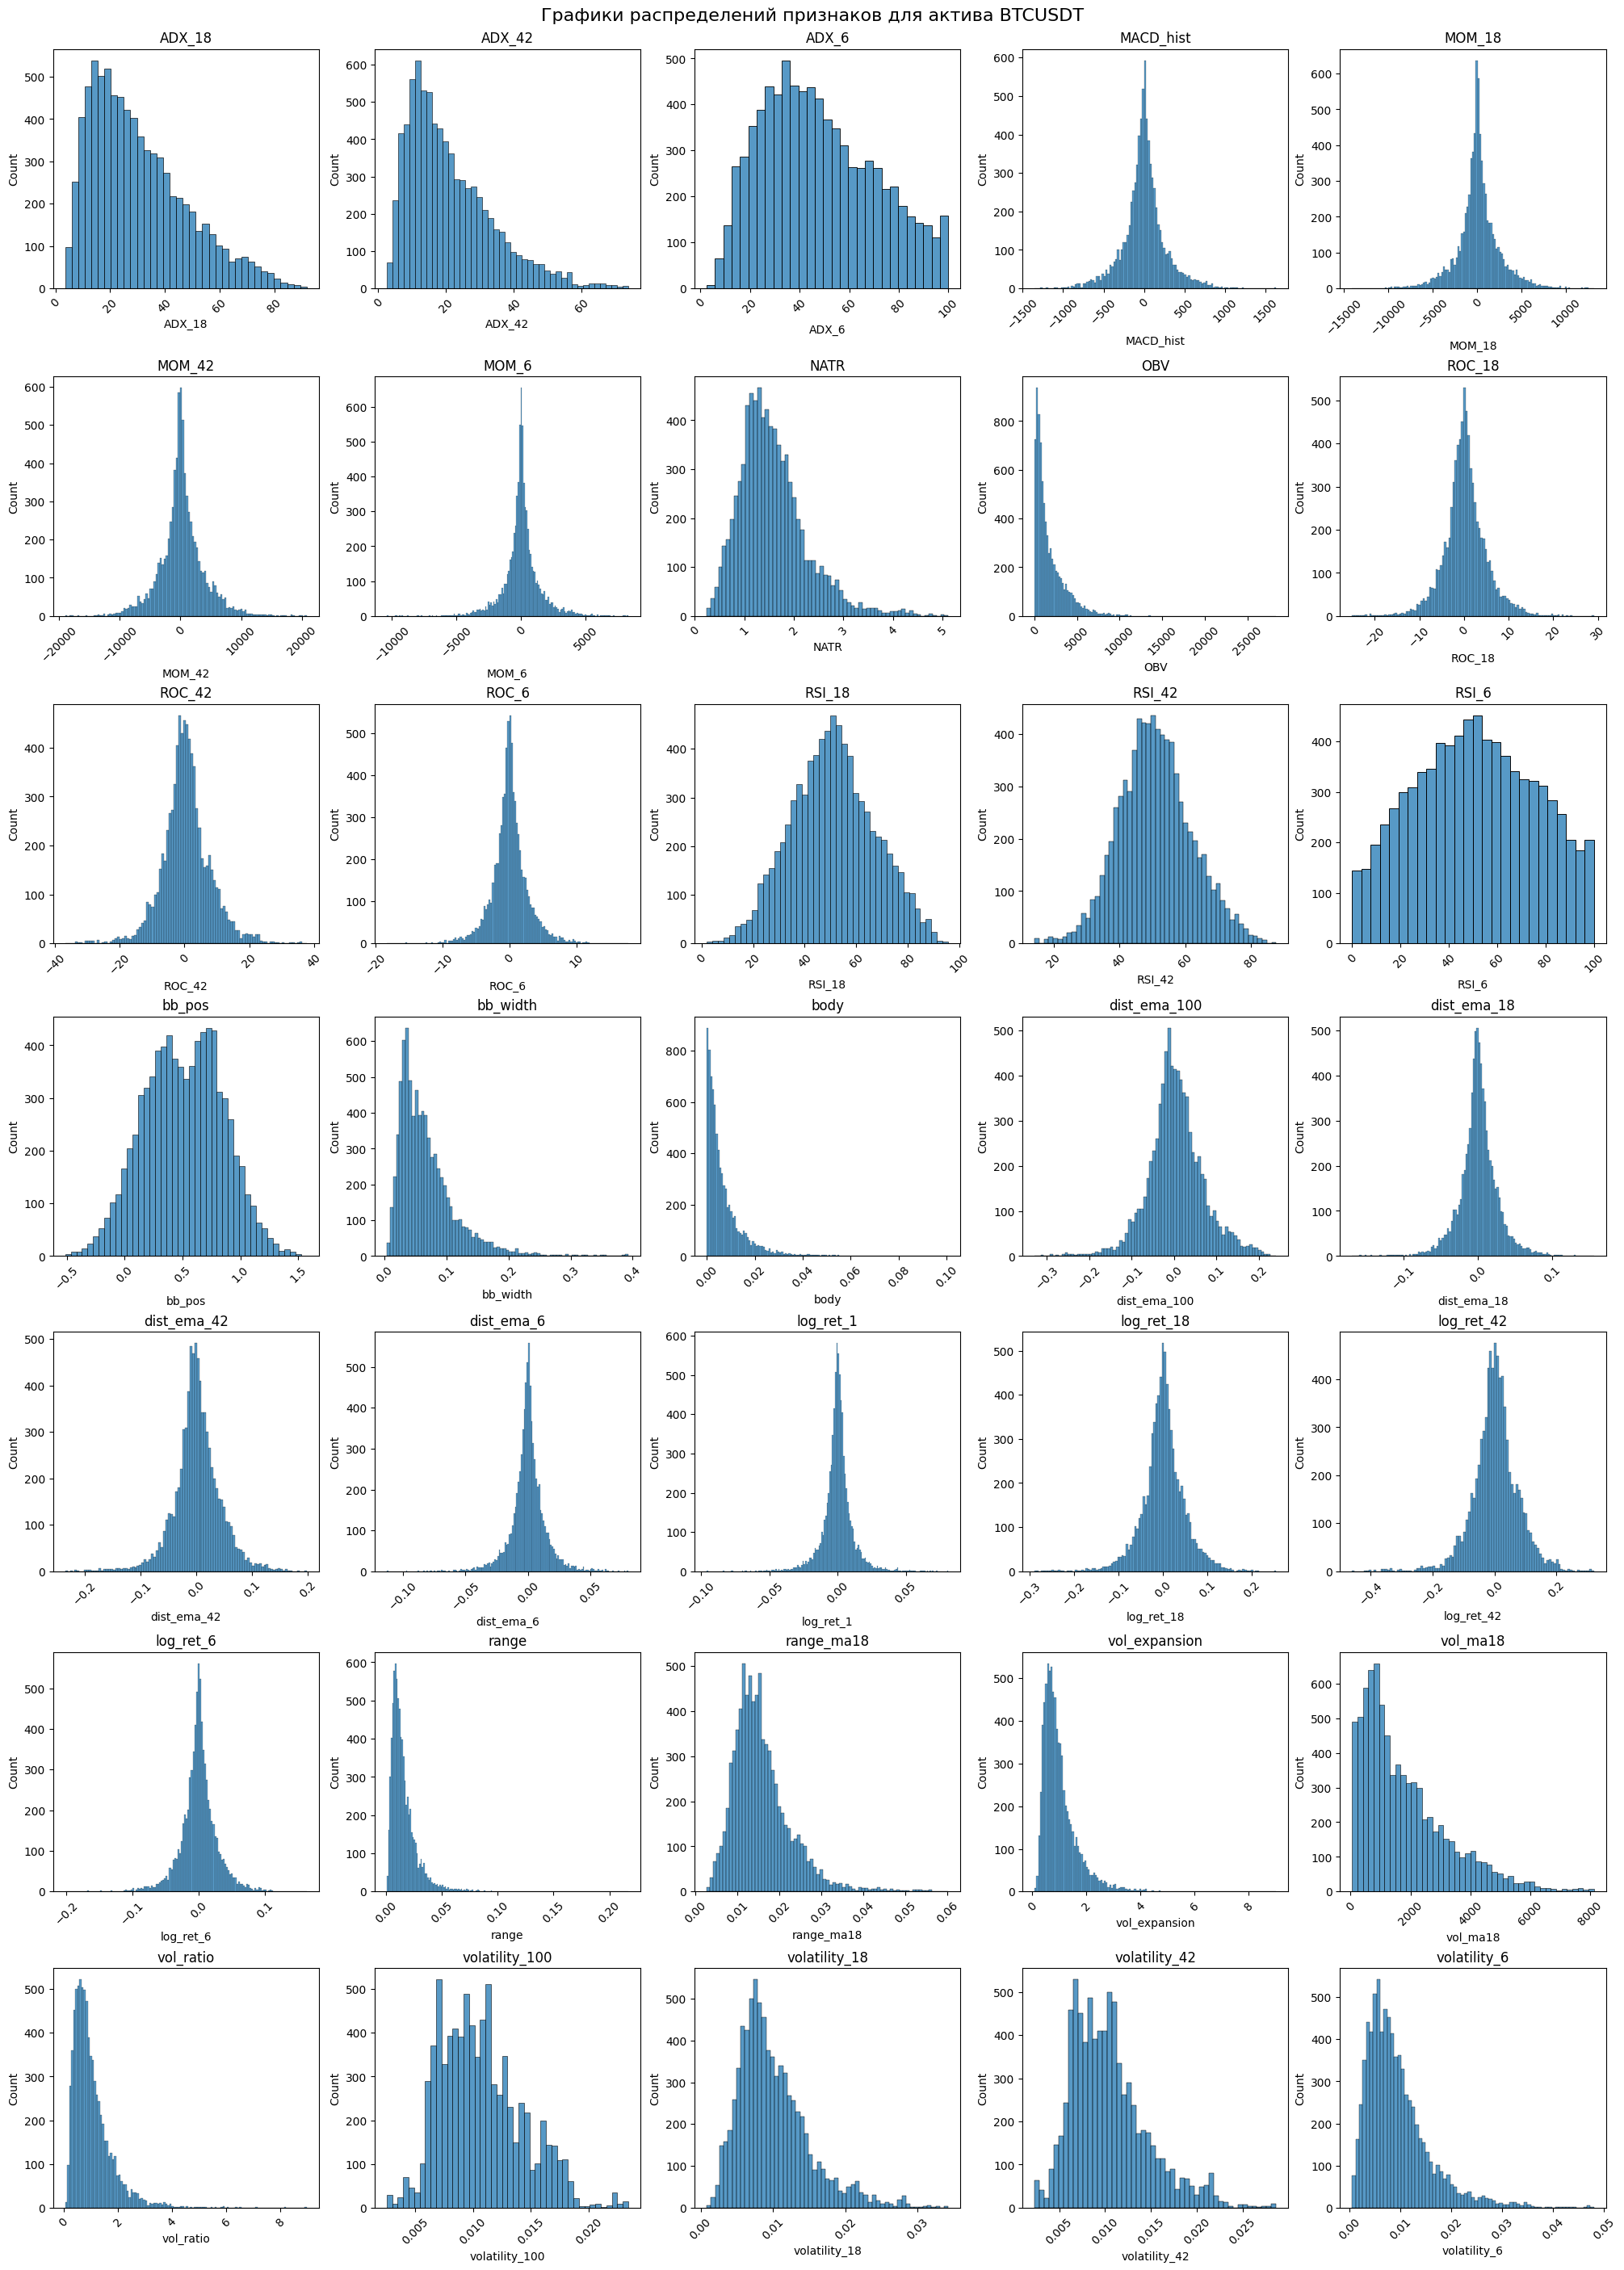

In [269]:
plot_feature_distributions(dataframe=df_indicators_asset, symbol=symbol)

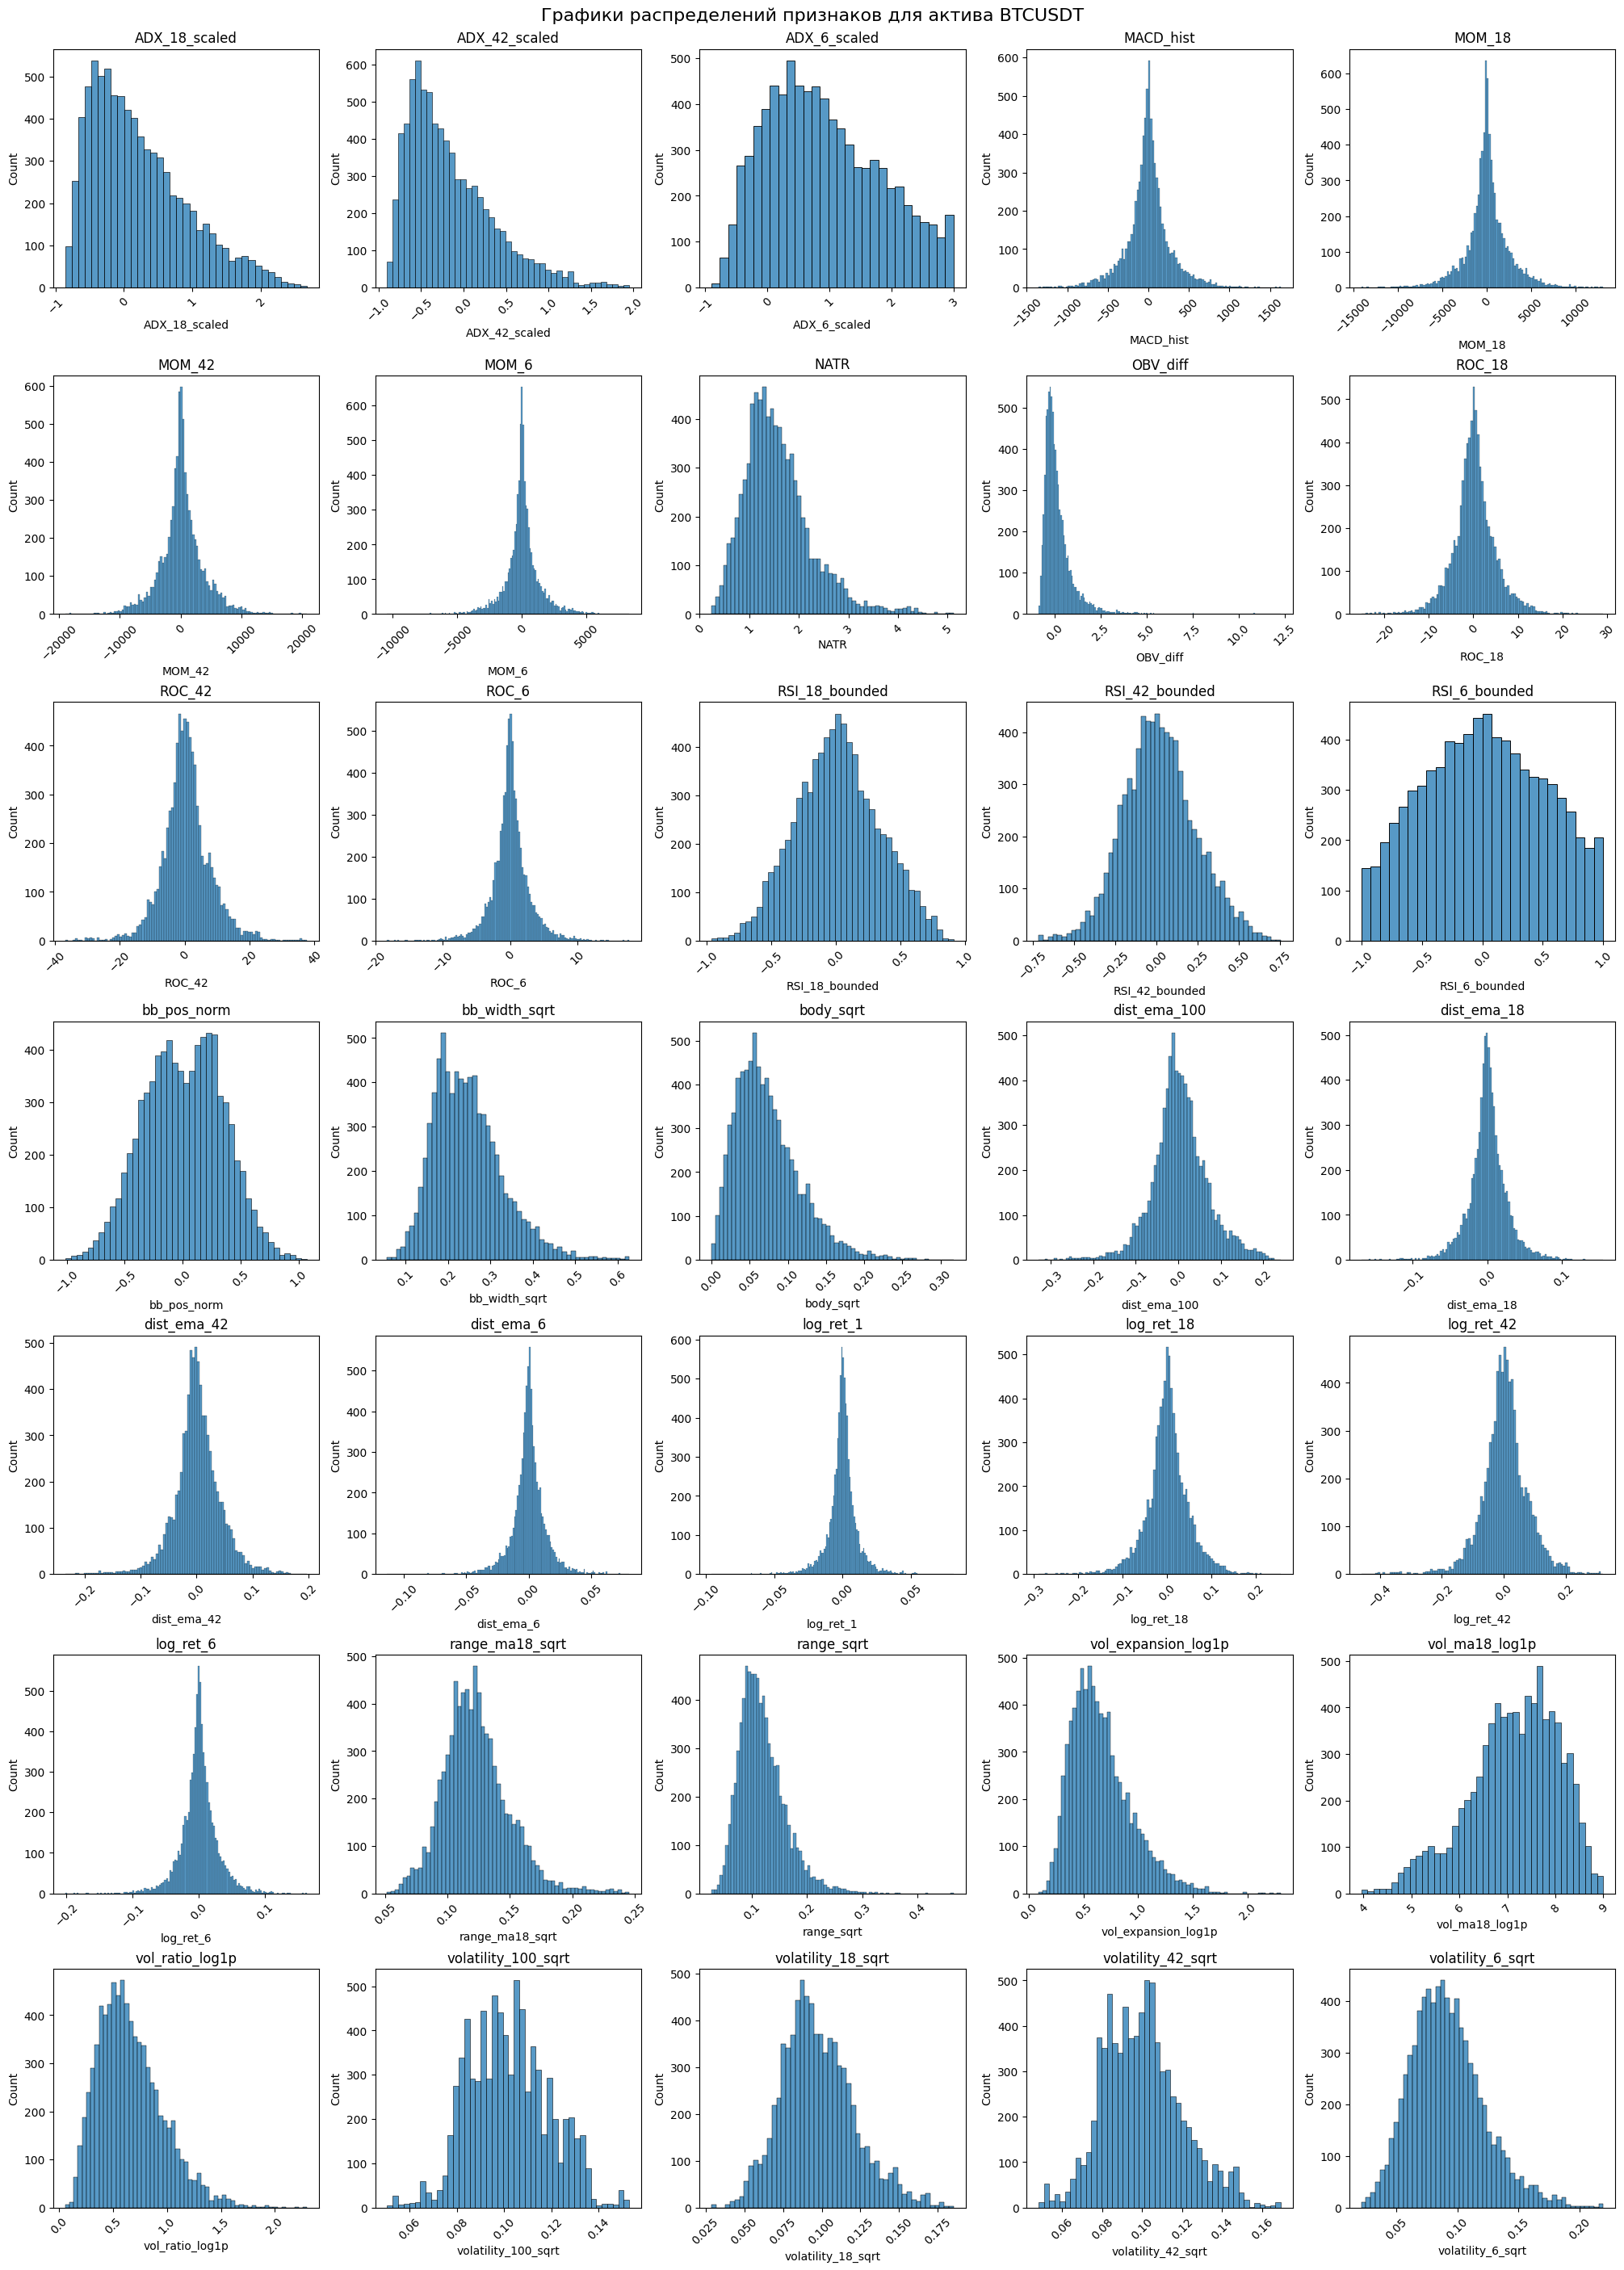

In [270]:
plot_feature_distributions(dataframe=df_transform_indicators_asset, symbol=symbol)

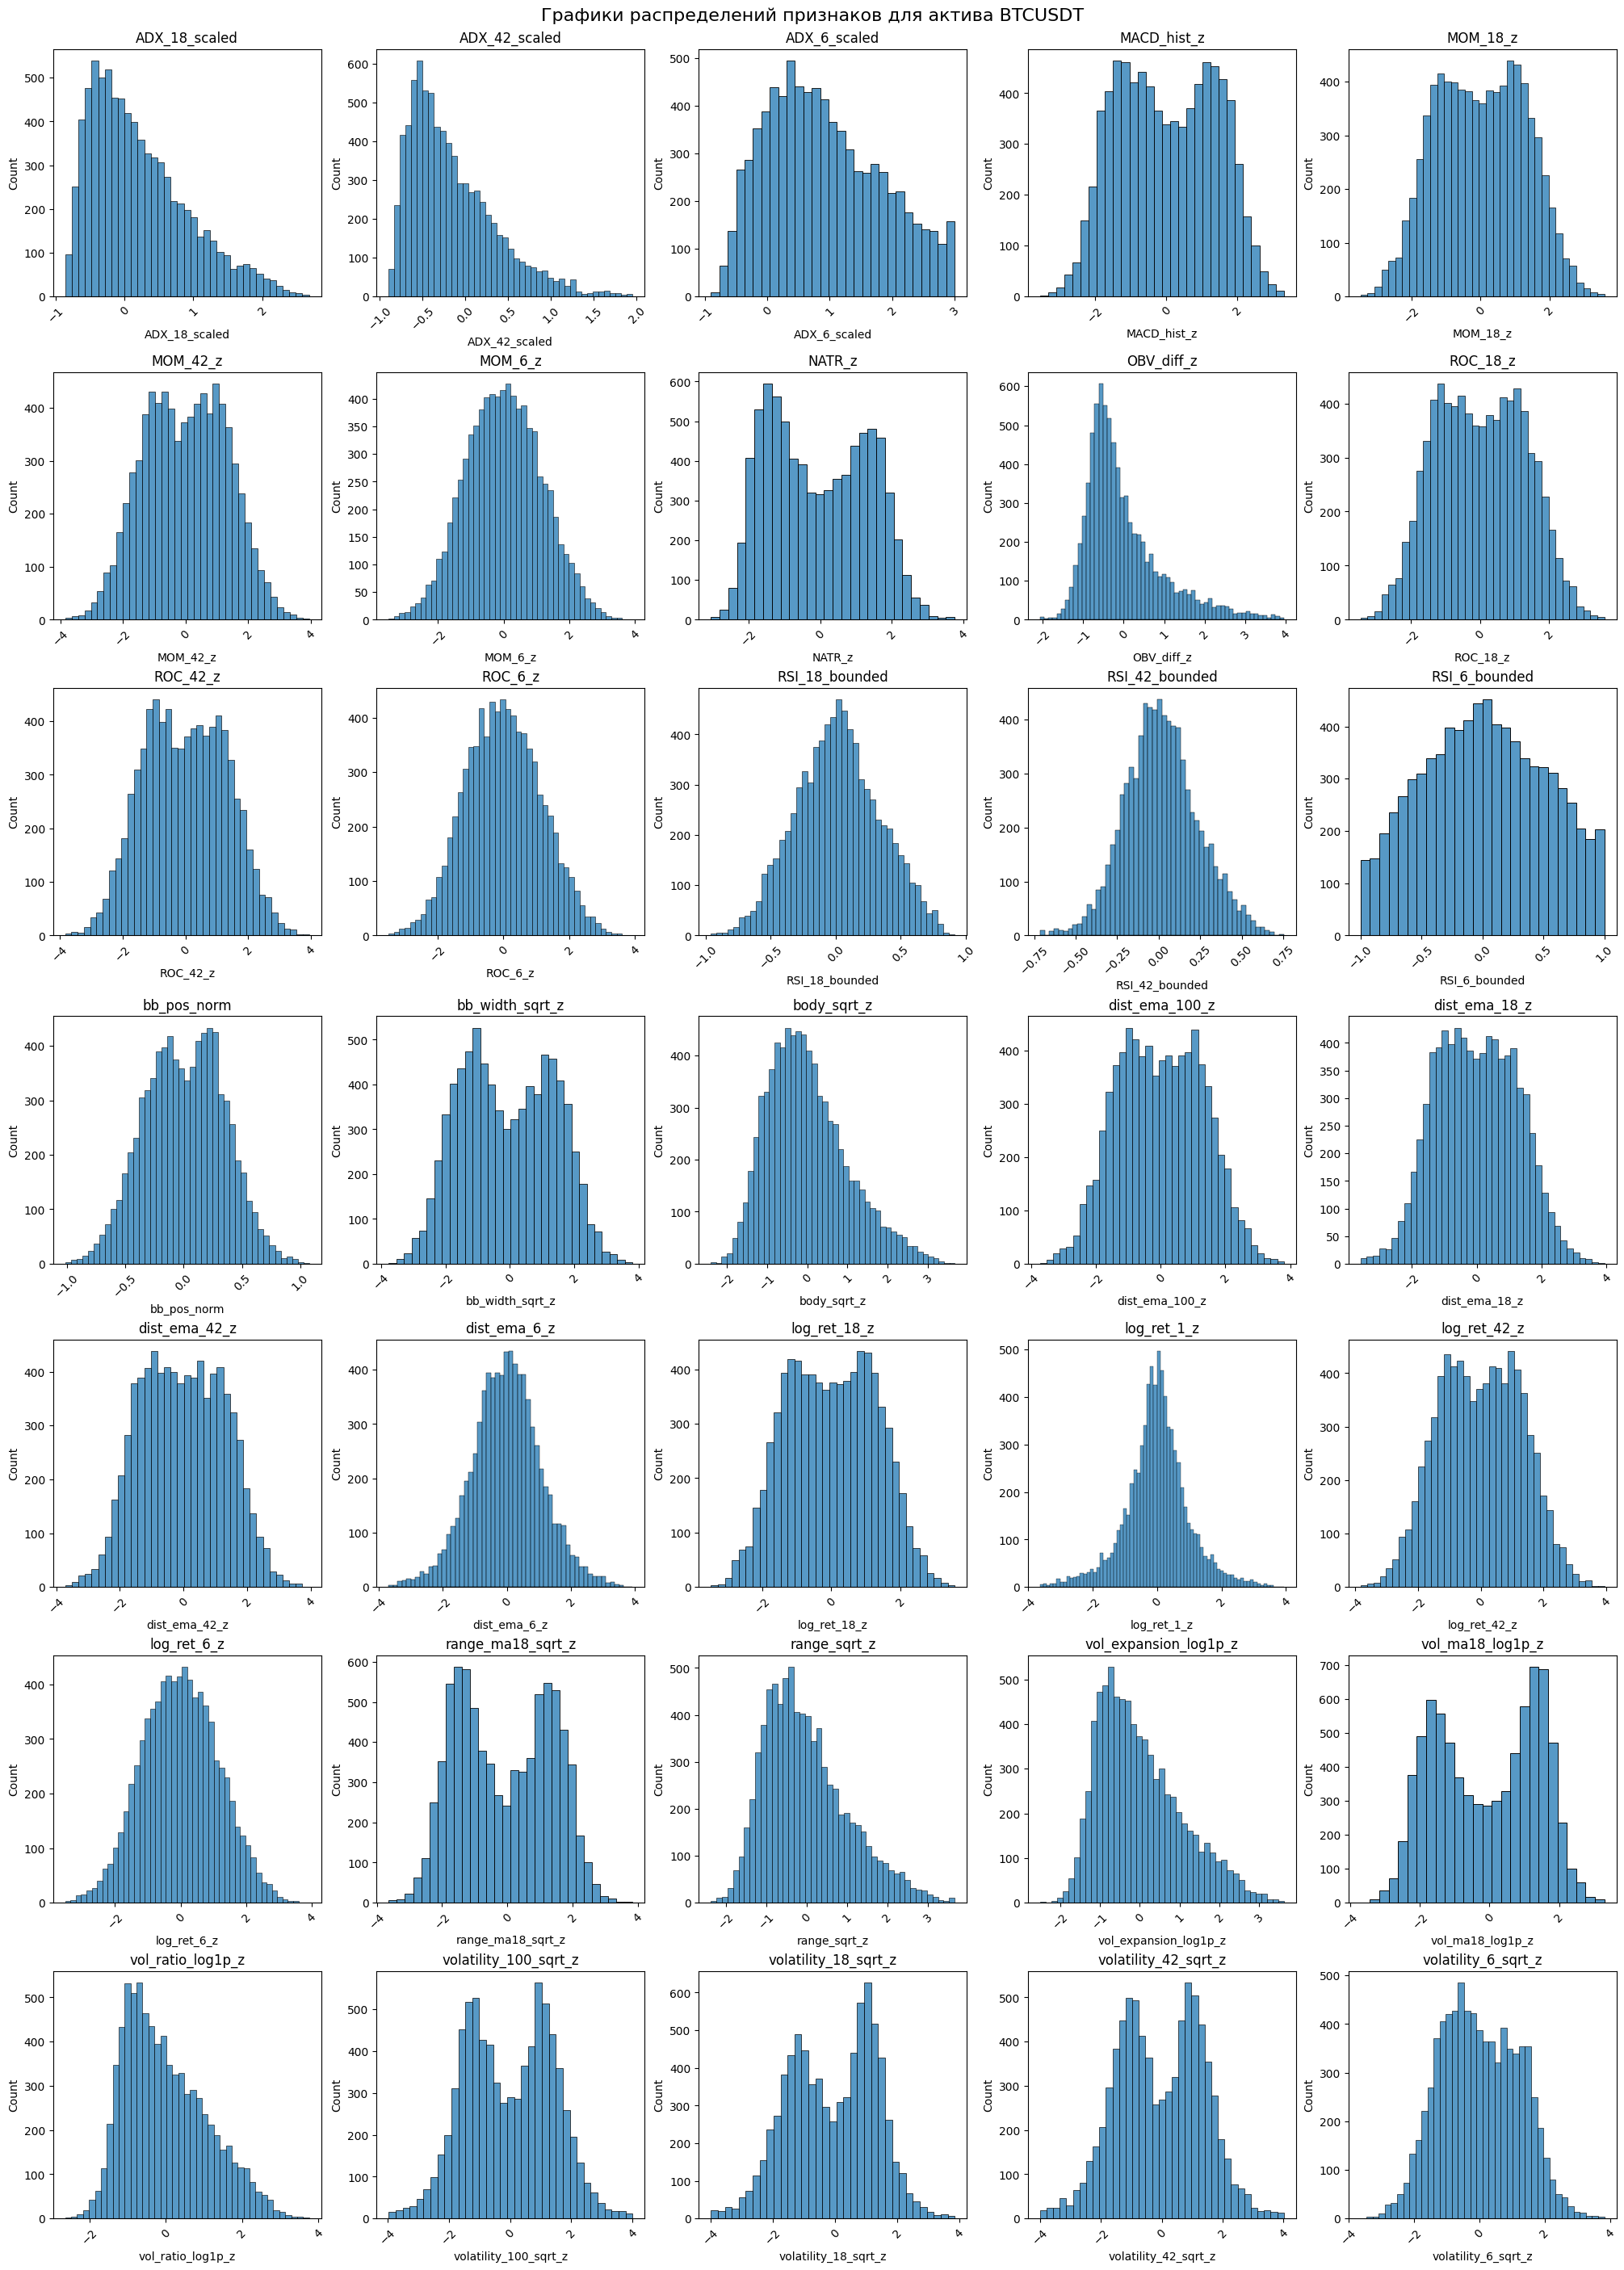

In [271]:
plot_feature_distributions(dataframe=df_z_score_indicators_asset, symbol=symbol)

**Матрица корреляций**

In [274]:
# В качестве target были выбраны лог доходности на несколько шагов вперёд
target_steps = 5
df_z_score_indicators_asset_with_targets = df_z_score_indicators_asset.copy()
for step in range(1, target_steps + 1):
    df_z_score_indicators_asset_with_targets[f'target_log_ret_step_{step}'] = np.log(
        df_z_score_indicators_asset['close'].shift(-step) / df_z_score_indicators_asset['close'])

df_z_score_indicators_asset_with_targets = df_z_score_indicators_asset_with_targets.dropna().reset_index(drop=True)

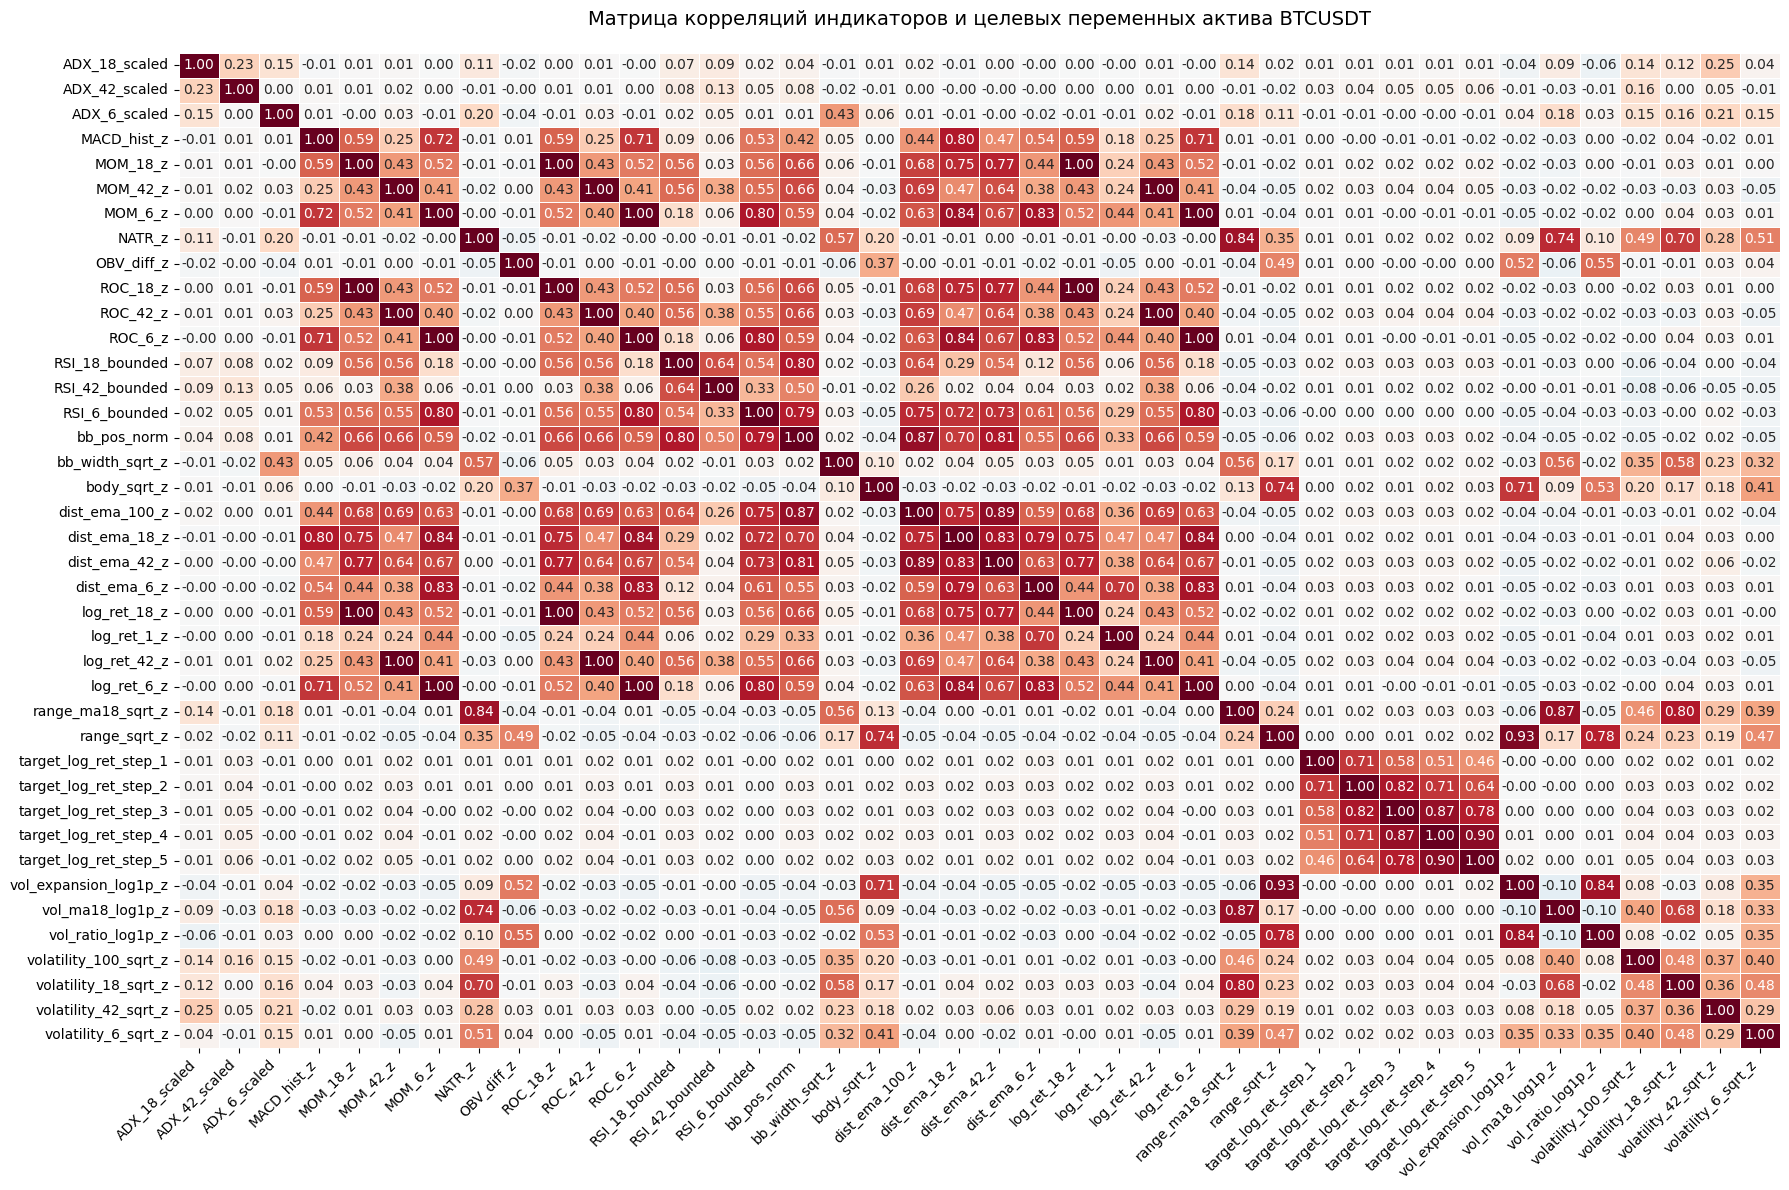

In [275]:
cols_for_corr = df_z_score_indicators_asset_with_targets.columns.difference(meta_cols)
corr_matrix = df_z_score_indicators_asset_with_targets[cols_for_corr].corr()
plt.figure(figsize=(18, 12))

sns.heatmap(corr_matrix,
            annot=True,
            fmt='.2f',
            cmap='RdBu_r',
            center=0,
            square=False,
            linewidths=0.5,
            linecolor='white',
            cbar=False)

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)

plt.title(
    f'Матрица корреляций индикаторов и целевых переменных актива {df_z_score_indicators_asset_with_targets['symbol'].unique()[0]}',
    fontsize=14, pad=20)
plt.tight_layout()
plt.show()

**Linear Thompson Sampling**

In [276]:
class DiscountedLinearTS:
    def __init__(
        self,
        n_features,
        actions,
        discount_factor=0.99,
        lambda_prior=1.0,
        noise_std=0.05,
        adaptive=True,
        trade_penalty=None,
        seed=42
    ):
        self.d = n_features
        self.actions = list(actions)

        self.gamma = discount_factor
        self.lambda_prior = lambda_prior
        self.noise_std = noise_std
        self.adaptive = adaptive
        self.trade_penalty = trade_penalty

        self.rng = np.random.default_rng(seed)

        self.I = np.eye(self.d)

        self.A = {
            a: lambda_prior * self.I.copy()
            for a in self.actions
        }

        self.b = {
            a: np.zeros(self.d, dtype=np.float64)
            for a in self.actions
        }

        self.A_inv = {
            a: (1.0 / lambda_prior) * self.I.copy()
            for a in self.actions
        }

    def _decay_action(self, action):
        self.A[action] = (
            self.gamma
            * (self.A[action] - self.lambda_prior * self.I)
            + self.lambda_prior * self.I
        )

        self.b[action] = self.gamma * self.b[action]

        self.A_inv[action] = np.linalg.inv(self.A[action])

    def select_action(self, x, valid_actions=None):
        x = np.asarray(x, dtype=np.float64).flatten()

        if valid_actions is None:
            valid_actions = self.actions

        scores = {}

        for a in valid_actions:
            A_inv = self.A_inv[a]
            mu = A_inv @ self.b[a]

            if self.adaptive:
                point_uncertainty = np.sqrt(
                    max(x @ A_inv @ x, 1e-12)
                )
                sigma = self.noise_std * point_uncertainty
            else:
                sigma = self.noise_std

            theta_sample = self.rng.multivariate_normal(
                mean=mu,
                cov=(sigma ** 2) * A_inv
            )

            score = float(x @ theta_sample)

            if self.trade_penalty is not None and a in [-1, 1]:
                score -= np.log(self.trade_penalty)

            scores[a] = score

        return max(scores, key=scores.get)

    def update(
        self,
        chosen_action,
        x,
        reward,
        valid_actions=None
    ):
        x = np.asarray(x, dtype=np.float64).flatten()

        if valid_actions is None:
            valid_actions = self.actions

        for a in valid_actions:
            self._decay_action(a)

        self.A[chosen_action] += np.outer(x, x)
        self.b[chosen_action] += reward * x

        self.A_inv[chosen_action] = np.linalg.inv(
            self.A[chosen_action]
        )

In [277]:
def count_usdt_final(final_asset_quantity, close_price, trade_cost):
    """Рассчитывает сумму выхода из сделки с учётом издержек"""
    asset_held = final_asset_quantity
    usdt_from_sale = asset_held * close_price
    fee_in_usdt = usdt_from_sale * trade_cost
    usdt_final = usdt_from_sale - fee_in_usdt

    return usdt_final

def count_entry_action(position_value, close_price, trade_cost):
    """Рассчитывает сумму входа в сделку с учётом издержек"""
    asset_bought = position_value / close_price
    fee_in_asset = asset_bought * trade_cost
    final_asset_quantity = asset_bought - fee_in_asset

    return final_asset_quantity

**Reward**

In [278]:
class Reward:
    def __init__(self, risk_adjust=False, factor=1, actions=None, window_size=48):
        if risk_adjust and actions is None:
            raise ValueError(
                f"Вы использует risk adjust оценку, но не передали actions"
            )
        if not risk_adjust and actions is not None:
            raise ValueError(
                f"Вы не использует risk adjust оценку, но передали actions"
            )
        if factor <= 0:
            raise ValueError(
                f"factor не может быть меньше или равен 0"
            )

        self.buffer_reward = {a: deque(maxlen=window_size) for a in actions} if risk_adjust else None
        self.threshold = window_size if risk_adjust else 2
        self.risk_adjust = risk_adjust
        self.factor = factor

    def _risk_adjust(self, reward, action):
        if self.risk_adjust:
            if action not in self.buffer_reward.keys():
                raise ValueError(
                    f"Получено неправомерное действие {action}"
                )
            self.buffer_reward[action].append(self.factor * reward)
            if len(self.buffer_reward[action]) < self.threshold:
                reward = self.factor * reward
            else:
                mean = np.array(self.buffer_reward[action]).mean()
                std = np.array(self.buffer_reward[action]).std(ddof=1)
                reward = (self.factor * reward - mean) / (std + 1e-6)
        else:
            reward = self.factor * reward

        return reward

    def reward_hold_out_position(self, close_price_now, close_price_next, penalty, action):
        profit_line_for_buy = close_price_now * penalty**2 # это линия цены, после которой идёт чистый плюсовой PnL с учётом двойной издержки.
        reward = None
        if close_price_next > profit_line_for_buy: # если цена ушла выше линии прибыли
            reward = -np.log(close_price_next/close_price_now) # -unrealized_PnL
        elif close_price_now <= close_price_next <= profit_line_for_buy: # Цена чуть двинулась в направлении тренда
            reward = 0.0 # если мы в флэт, то дальнейшее движение может быть как тренд вверх, так и вниз. Лучше нейтральный reward
        elif close_price_next < close_price_now: # если цена ушла вниз
            reward = -np.log(close_price_next/close_price_now) # даём положительный reward как сохранение капитала

        return self._risk_adjust(reward, action)

    def reward_buy(self, close_price_now, close_price_next, penalty, action):
        reward = -np.log(penalty**2) # Платим двойную издержку, как за вход, так и за выход. Действие BUY отвествено перед последующим SELL. Закладываем в это действие порог вхождения в сделку.
        return self._risk_adjust(reward, action)

    def reward_hold_in_position(self, close_price_now, close_price_next, entry_close_price, penalty, action):
        reward = None
        profit_line_for_sell = entry_close_price * penalty**2 # это линия цены выходы из сделки, после которой идёт чистая прибыль с учётом издержек в две стороны. Всё что ниже этой линии при SELL будет давать -PnL.
        if entry_close_price <= close_price_now <= profit_line_for_sell: # если мы находимся между ценой входа и ценой прибыли
            if entry_close_price <= close_price_next <= profit_line_for_sell: # и если цена осталась на следующем шаге в этом же диапазоне. Это флэт.
                reward = 0.0001 # если мы в флэт, то дальнейшее движение может быть как тренд вверх, так и вниз. Поэтому лучше воздержаться, иначе при выходе мы понесём потери
            elif close_price_next > profit_line_for_sell: # если цена поднялась выше линии безубыточности
                reward = np.log(close_price_next/profit_line_for_sell) # считаем чистую прибыль
            elif close_price_next < entry_close_price: # если цена опустилась ниже цены входа
                reward = np.log(close_price_next/profit_line_for_sell) # считаем чистый убыток
        elif close_price_now > profit_line_for_sell: # если мы находимся выше линии безубыточности
            reward = np.log(close_price_next/close_price_now) # reward равен изменению PnL
        elif close_price_now < entry_close_price: # если мы находимся ниже цены входа
            reward = np.log(close_price_next/close_price_now) # reward равен изменению PnL

        return self._risk_adjust(reward, action)

    def reward_sell(self, close_price_now, close_price_next, entry_close_price, penalty, action):
        profit_line_for_sell = entry_close_price * penalty**2 # это линия цены выходы из сделки, после которой идёт чистая прибыль с учётом издержек в две стороны. Всё что ниже этой линии при SELL будет давать -PnL.
        reward = None
        if close_price_next > close_price_now: # если цена выросла на следующем шаге
            reward = np.log(close_price_now/profit_line_for_sell) # считаем чистую прибыль, не учитываем следующий бар, чтобы не занижать sell
        else: # если цена упала на следующем шаге
            reward = np.log(close_price_now/profit_line_for_sell) - np.log(close_price_next/close_price_now) # считаем чистую прибыль + награда за выход перед падением

        return self._risk_adjust(reward, action)

**Backtesting**

In [279]:
def get_klines(time, symbols, df):
    '''
    Позволяет получить 4-часовые свечи

    :param time: (datetime) текущий временной шаг
    :param symbols: (List[str]) список активов для которых запрашиваем свечи
    :param df: (DataFrame) датафрейм с данными OHLCV по каждому активу и временному шагу
    :return: df[mask]: (DataFrame) данные OHLCV по запрашиваемым активам symbols на временном шаге time
    '''
    mask = (df['timestamp'] == time) & (df['symbol'].isin(symbols))
    return df[mask]

In [280]:
class DrawdownTracker:
    """Считаем просадку относительно максимальной цены"""
    def __init__(self, entry_price):
        self.entry_price = entry_price
        self.max_price = entry_price
        self.max_drawdown = 0.0
        self.current_dd = 0.0

    def update(self, current_price):
        self.max_price = max(self.max_price, current_price)
        self.current_dd = (self.max_price - current_price) / self.max_price
        self.max_drawdown = max(self.max_drawdown, self.current_dd)

    def reset(self, entry_price):
        self.entry_price = entry_price
        self.max_price = entry_price
        self.max_drawdown = 0.0
        self.current_dd = 0.0

    def get_max_drawdown(self):
        return self.max_drawdown

    def get_current_dd(self):
        return self.current_dd

class State:
    """Храним признаки состояния для обогащения контекста бандита"""
    def __init__(self):
        self.state_dict = {
            'in_position': 0, # False
            'drawdown': 0,
            'bars_in_hold': -1,
            'pnl_zone': 0 # -1, 0, 1
        }

    def update(self, current_price, entry_price, penalty, current_dd):
        profit_line = entry_price * penalty**2

        if current_price > profit_line:
            self.state_dict['pnl_zone'] = 1
        elif current_price >= entry_price:
            self.state_dict['pnl_zone'] = 0
        else:
            self.state_dict['pnl_zone'] = -1

        self.state_dict['drawdown'] = current_dd
        self.state_dict['bars_in_hold'] += 1

    def set_position(self, position):
        self.state_dict['in_position'] = position

    def reset(self):
        self.state_dict['in_position'] = 0
        self.state_dict['drawdown'] = 0
        self.state_dict['bars_in_hold'] = -1
        self.state_dict['pnl_zone'] = 0

    def get_state_dict(self):
        return self.state_dict

    def get_position_info(self):
        return self.state_dict['in_position']

In [281]:
class Backtesting:
    def __init__(
            self,
            meta_cols,
            config_for_stream_ta_lib_function,
            config_for_rolling_z_score_standardization,
            config_for_bandit,
            config_for_reward,
            seed=42,
            buffer_size=100,
            trade_cost=0.001
    ):
        self.seed = seed
        self.meta_cols = meta_cols
        self.buffer_size = buffer_size
        self.config_for_stream_ta_lib_function=config_for_stream_ta_lib_function
        self.rolling_z_score_standardization = rolling_z_score_clip_online(**config_for_rolling_z_score_standardization)
        self.trade_cost = trade_cost
        self.config_for_bandit = config_for_bandit

        self.klines_buffer = {}  # сохраняет последние self.buffer_size данных о свечах OHLCV по каждому активу
        self.symbols = []
        self.features_cols = None
        self.bandits = {}

        # Статистика обучения для графиков
        self.actions_train = {}
        self.rewards_train = {}
        self.balance_train = {}
        self.times_train = {}
        self.close_train = {}

        # Статистика валидации для графиков
        self.actions_val = {}
        self.rewards_val = {}
        self.balance_val = {}
        self.times_val = {}
        self.close_val = {}

        self.reward = Reward(**config_for_reward)

        self.trade_penalty = 1/(1-self.trade_cost) # издержка в одну сторону при покупке или продаже

    @staticmethod
    def get_bandit_context(market_context, state):
        state_dict = state.get_state_dict()

        in_position = state_dict['in_position']
        drawdown = state_dict['drawdown']
        bars_in_hold = state_dict['bars_in_hold']
        pnl_zone = state_dict['pnl_zone']

        bars_in_hold_norm = np.log1p(bars_in_hold)

        state_context = [in_position, drawdown, bars_in_hold_norm, pnl_zone]

        bandit_context = np.concatenate([market_context, state_context], axis=0)
        return bandit_context

    def backtest(self, dataframe_train, dataframe_val, symbols, start_capital=100, position_size=0.1):
        missed_meta_cols = []
        for col in self.meta_cols:
            if col not in dataframe_train.columns:
                missed_meta_cols.append(col)
        if missed_meta_cols:
            raise ValueError(
                f"В train_df отсутствуют мета-колонки: {', '.join(missed_meta_cols)}"
            )

        missed_meta_cols = []
        for col in self.meta_cols:
            if col not in dataframe_val.columns:
                missed_meta_cols.append(col)
        if missed_meta_cols:
            raise ValueError(
                f"В val_df отсутствуют мета-колонки: {', '.join(missed_meta_cols)}"
            )

        for sym in symbols:
            if sym not in ALL_SYMBOLS:
                raise ValueError(
                    f"Актив {sym} отсутствует. Список доступных активов: {ALL_SYMBOLS}"
                )
            if sym not in dataframe_train['symbol'].unique():
                raise ValueError(
                    f"В train_df отсутствует актив: {sym}"
                )
            if sym not in dataframe_val['symbol'].unique():
                raise ValueError(
                    f"В val_df отсутствует актив: {sym}"
                )

        # Заводим буферы для сохранения обученного агента и истории обучения
        for sym in symbols:
            self.symbols.append(sym)
            self.klines_buffer[sym] = pd.DataFrame()
            self.rolling_z_score_standardization.reset_statistics_by_symbol(sym)

            self.actions_train[sym] = []
            self.rewards_train[sym] = defaultdict(list)
            self.balance_train[sym] = []
            self.times_train[sym] = []
            self.close_train[sym] = []

            self.actions_val[sym] = []
            self.rewards_val[sym] = defaultdict(list)
            self.balance_val[sym] = []
            self.times_val[sym] =[]
            self.close_val[sym] = []

            self.bandits[sym] = DiscountedLinearTS(**config_for_bandit)
        self.symbols = list(set(self.symbols))

        train_phase = True
        current_dataframe = dataframe_train

        # буферы для цикла бектеста
        cash = {sym: start_capital for sym in symbols} # сколько денег на балансе
        entry_close_price = {sym: None for sym in symbols} # цена входа в позицию для расчёта reward для sell
        assets = {sym: None for sym in symbols} # количество купленного актива
        time = current_dataframe['timestamp'].min() # текущее время
        state = {sym: State() for sym in symbols} # состояние для обогащения контекста при входе в позицию
        dd_tracker = {sym: DrawdownTracker(-float('inf')) for sym in symbols} # заводим трекер просадок

        print(f"Фаза обучения началась: {time}")
        while True:
            current_klines = get_klines(time, symbols, current_dataframe)

            if current_klines.empty and train_phase:
                print(f"Обучение закончилось. Время: {time}")
                print(f"Фаза валидации началась {time}")

                train_phase = False
                current_dataframe = dataframe_val

                cash = {sym: start_capital for sym in symbols}
                entry_close_price = {sym: None for sym in symbols}
                assets = {sym: None for sym in symbols}
                time = current_dataframe['timestamp'].min()
                state = {sym: State() for sym in symbols}
                dd_tracker = {sym: DrawdownTracker(-float('inf')) for sym in symbols}

                current_klines = get_klines(time, symbols, current_dataframe)
            elif current_klines.empty and not train_phase:
                print(f"Валидация закончилась. Время: {time}")
                break

            for sym in symbols:
                sym_current_kline = current_klines[current_klines['symbol'] == sym]
                if not sym_current_kline.empty:
                    self.klines_buffer[sym] = pd.concat([self.klines_buffer[sym], sym_current_kline]).sort_values('timestamp').reset_index(drop=True)

            current_min_buffer_size = min([sym_klines_df.shape[0] for sym_klines_df in self.klines_buffer.values()])
            if current_min_buffer_size < self.buffer_size:
                time += pd.Timedelta(hours=4)
                continue

            if current_min_buffer_size == self.buffer_size:
                print("\t\tБуфер заполнен")
                print(f"Текущее время {time}")
                for sym, sym_klines_df in self.klines_buffer.items():
                    print(
                        f"Актив {sym}, размер буфера {sym_klines_df.shape[0]}, период {sym_klines_df['timestamp'].min()} - {sym_klines_df['timestamp'].max()}")
                    display(sym_klines_df)

            for sym in symbols:
                sym_klines_df = self.klines_buffer[sym]

                # Расчёт сырых индикаторов
                sym_raw_indicators = pd.DataFrame([stream_TA_lib(sym_klines_df, meta_cols=self.meta_cols, **self.config_for_stream_ta_lib_function)])

                sym_klines_df = sym_klines_df[sym_klines_df['timestamp'] != time]

                sym_klines_df = pd.concat([sym_klines_df, sym_raw_indicators], ignore_index=True).sort_values('timestamp').reset_index(drop=True)

                sym_klines_df = sym_klines_df.tail(self.buffer_size).sort_values('timestamp').reset_index(drop=True)

                self.klines_buffer[sym] = sym_klines_df

                # Трансформация индикатор к нормализованному виду
                sym_transform_indicators = transform_online(sym_klines_df, meta_cols=self.meta_cols)

                # Применение скользящей z-score к индикаторам
                sym_z_score_indicators = pd.DataFrame([self.rolling_z_score_standardization.rolling_z_score_clip(sym_transform_indicators, meta_cols=self.meta_cols, symbol=sym)])

                if sym_z_score_indicators.isna().sum().sum():
                    continue

                if self.features_cols is None:
                    self.features_cols = sym_z_score_indicators.columns.difference(self.meta_cols)

                market_context = sym_z_score_indicators[self.features_cols].values[0]
                current_close_price = sym_z_score_indicators['close'].iloc[0]
                future_close_price = sym_z_score_indicators['future_close_price'].iloc[0]
                position = state[sym].get_position_info()

                dd_tracker[sym].update(current_close_price)

                if position == 0:
                    available_actions = [0, 1]
                    state[sym].update(current_price=current_close_price, entry_price=current_close_price, penalty=self.trade_penalty, current_dd=dd_tracker[sym].get_current_dd())
                else:
                    available_actions = [-1, 0]
                    state[sym].update(current_price=current_close_price, entry_price=entry_close_price[sym], penalty=self.trade_penalty, current_dd=dd_tracker[sym].get_current_dd())

                bandit_context = self.get_bandit_context(market_context, state[sym])
                action = self.bandits[sym].select_action(bandit_context, valid_actions=available_actions)
                if action not in available_actions:
                    raise ValueError(
                        f"Недоступное действие: {action}"
                    )

                if train_phase:
                    self.actions_train[sym].append(action)
                    self.times_train[sym].append(pd.to_datetime(time))
                    self.close_train[sym].append(current_close_price)
                else:
                    self.actions_val[sym].append(action)
                    self.times_val[sym].append(pd.to_datetime(time))
                    self.close_val[sym].append(current_close_price)

                if action == 1:
                    state[sym].reset()
                    state[sym].set_position(1)
                    dd_tracker[sym].reset(current_close_price)

                    position_value = cash[sym] * position_size
                    assets[sym] = count_entry_action(position_value, current_close_price, self.trade_cost)
                    cash[sym] -= position_value

                    entry_close_price[sym] = current_close_price

                    reward = self.reward.reward_buy(
                        close_price_now=current_close_price,
                        close_price_next=future_close_price,
                        penalty=self.trade_penalty,
                        action=action
                    )
                elif action == -1:
                    reward = self.reward.reward_sell(
                        close_price_now=current_close_price,
                        close_price_next=future_close_price,
                        entry_close_price=entry_close_price[sym],
                        penalty=self.trade_penalty,
                        action=action
                    )
                    state[sym].reset()
                    dd_tracker[sym].reset(current_close_price)

                    exit_value = count_usdt_final(assets[sym], current_close_price, self.trade_cost)
                    cash[sym] += exit_value
                    if train_phase:
                        self.balance_train[sym].append(cash[sym])
                    else:
                        self.balance_val[sym].append(cash[sym])
                elif action == 0 and position == 0:
                    reward = self.reward.reward_hold_out_position(
                        close_price_now=current_close_price,
                        close_price_next=future_close_price,
                        penalty=self.trade_penalty,
                        action=action
                    )
                elif action == 0 and position == 1:
                    reward = self.reward.reward_hold_in_position(
                        close_price_now=current_close_price,
                        close_price_next=future_close_price,
                        entry_close_price=entry_close_price[sym],
                        penalty=self.trade_penalty,
                        action=action
                    )
                else:
                    raise ValueError(
                        "Непредвиденное поведение!"
                    )

                self.bandits[sym].update(action, bandit_context, reward)

                if train_phase:
                    self.rewards_train[sym][action].append(reward)
                else:
                    self.rewards_val[sym][action].append(reward)

            time += pd.Timedelta(hours=4)

    def plots(self, mode_train, symbols=None, Balance_equity=True, Actions_equity=False, Reward_stats=False):
        if mode_train:
            actions = self.actions_train
            rewards = self.rewards_train
            balance = self.balance_train
            times = self.times_train
            prices = self.close_train
        else:
            actions = self.actions_val
            rewards = self.rewards_val
            balance = self.balance_val
            times = self.times_val
            prices = self.close_val

        if symbols is None:
            symbols = self.symbols
        else:
            for sym in symbols:
                if sym not in self.symbols:
                    raise ValueError(
                        f"Актив {sym} отсутствует. Список активов агента: {self.symbols}"
                    )

        for sym in symbols:
            counts_actions = Counter(actions[sym])
            for act, val in counts_actions.items():
                print(f"{sym}: {act} = {val}")
            print('-'*20)

        if Balance_equity:
            fig, axes = plt.subplots(len(symbols), 1, figsize=(20, len(symbols) * 7))

            if len(symbols) == 1:
                axes = [axes]

            for idx, sym in enumerate(symbols):
                sns.lineplot(balance[sym], ax=axes[idx])
                axes[idx].set_title(f'Symbol: {sym}')
                axes[idx].set_ylabel('Balance')
                axes[idx].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

        if Actions_equity:
            fig, axes = plt.subplots(len(symbols), 1, figsize=(20, len(symbols) * 7))

            if len(symbols) == 1:
                axes = [axes]

            for idx, sym in enumerate(symbols):
                # Преобразуем списки в pandas Series для удобной работы
                times_series = pd.Series(times[sym])
                prices_series = pd.Series(prices[sym])

                # Строим график цены
                axes[idx].plot(times_series, prices_series, label=str(sym), linewidth=1)

                # Создаем DataFrame с действиями
                actions_df = pd.DataFrame({
                    'timestamp': times_series,
                    'close': prices_series,
                    'action': actions[sym]
                }).sort_values('timestamp')

                # Отмечаем покупки (action=1)
                buy = actions_df[actions_df["action"] == 1]
                if not buy.empty:
                    axes[idx].scatter(
                        buy["timestamp"],
                        buy["close"],
                        marker="^",
                        color="green",
                        s=70,
                        label="BUY",
                        zorder=5
                    )

                # Отмечаем продажи (action=-1)
                sell = actions_df[actions_df["action"] == -1]
                if not sell.empty:
                    axes[idx].scatter(
                        sell["timestamp"],
                        sell["close"],
                        marker="v",
                        color="red",
                        s=70,
                        label="SELL",
                        zorder=5
                    )

                axes[idx].set_title(f"Symbol: {sym}")
                axes[idx].set_xlabel("Timestamp")
                axes[idx].set_ylabel("Close Price")
                axes[idx].legend()
                axes[idx].grid(True, alpha=0.3)

            plt.tight_layout()
            plt.show()

        if Reward_stats:
            for sym in symbols:
                actions_name = list(rewards[sym].keys())
                rewards_data = [[reward for reward in rewards[sym][action]] for action in actions_name]

                colors = ['lightblue', 'lightgreen', 'lightcoral', 'lightsalmon']

                fig, axes = plt.subplots(2, 2, figsize=(14, 10))

                axes = axes.flatten()

                for idx, action in enumerate(actions_name):
                    ax = axes[idx]
                    ax.hist(rewards_data[idx], bins=20, alpha=0.7, color=colors[idx % len(colors)], edgecolor='black')
                    ax.set_title(f'Распределение наград: {action}', fontsize=12, fontweight='bold')
                    ax.set_xlabel('Награда', fontsize=10)
                    ax.set_ylabel('Частота', fontsize=10)
                    ax.grid(True, alpha=0.3)
                    ax.axvline(np.mean(rewards_data[idx]), color='red', linestyle='--',
                               label=f'Среднее: {np.mean(rewards_data[idx]):.3f}')
                    ax.legend()

                fig.suptitle(f"Символ {sym}")
                plt.tight_layout()
                plt.show()

                print("=" * 60)
                print("СТАТИСТИКА ПО ДЕЙСТВИЯМ:")
                print("=" * 60)

                for idx, action in enumerate(actions_name):
                    print(f"\n{action}:")
                    print(f"  Количество: {len(rewards_data[idx])}")
                    print(f"  Среднее: {np.mean(rewards_data[idx]):.4f}")
                    print(f"  Медиана: {np.median(rewards_data[idx]):.4f}")
                    print(f"  Стандартное отклонение: {np.std(rewards_data[idx]):.4f}")
                    print(f"  Минимум: {np.min(rewards_data[idx]):.4f}")
                    print(f"  Максимум: {np.max(rewards_data[idx]):.4f}")
                    print(f"  25-й перцентиль: {np.percentile(rewards_data[idx], 25):.4f}")
                    print(f"  75-й перцентиль: {np.percentile(rewards_data[idx], 75):.4f}")

In [285]:
SEED = 142

# Stream TA-lib settings
indicators_name = ['ADX', 'MOM', 'ROC', 'body', 'bb_width', 'dist_ema', 'log_ret', 'volatility', 'NATR']
filter_indicators_name = ['ADX_42', 'MOM_18', 'ROC_42', 'body', 'bb_width', 'dist_ema_6', 'log_ret_1', 'volatility_100', 'NATR'] # Отбор по корреляции пирсона
dist_ema_periods = [6]
momentum_indicators_periods = [18, 42]
return_indicators_periods = [1]
volatility_indicators_periods = [100]
vol_ma_period = None
range_ma_period = None
compute_all_indicators = False

# indicators_name = None
# filter_indicators_name=None
# dist_ema_periods = [6, 18, 42, 100]
# momentum_indicators_periods = [6, 18, 42]
# return_indicators_periods = [1, 6, 18, 42]
# volatility_indicators_periods = [6, 18, 42, 100]
# vol_ma_period = 18
# range_ma_period = 18
# compute_all_indicators = True

# Rolling z-score settings
window_rolling_z_score = 48
clip_value = 5
warmup_use = True

# Backtesting settings
start_capital = 100
trade_cost = 0.0025 # 0.001 transaction cost + 0.0015 slippage
position_size = 0.1

# Bandit settings
discount_factor = 0.8
noise_std = 0.001
lambda_prior = 1.0
actions = (-1, 0, 1) # SELL HOLD BUY
position_features = 4
trade_penalty = None
adaptive = False

# Reward settings
risk_adjust = False
factor = 1
window_size = 48
actions_reward = None # or actions

config_for_stream_ta_lib_function = {
    'indicators_name': indicators_name,
    'filter_indicators_name': filter_indicators_name,
    'dist_ema_periods': dist_ema_periods,
    'momentum_indicators_periods': momentum_indicators_periods,
    'return_indicators_periods': return_indicators_periods,
    'volatility_indicators_periods': volatility_indicators_periods,
    'vol_ma_period': vol_ma_period,
    'range_ma_period': range_ma_period,
    'compute_all_indicators': compute_all_indicators,
}

config_for_rolling_z_score_standardization = {
    'window': window_rolling_z_score,
    'clip_value': clip_value,
    'warmup': warmup_use
}

random_df = pd.DataFrame(np.random.random((HISTORICAL_WINDOW_SIZE, len(meta_cols))), columns=meta_cols)
n_features = len(pd.DataFrame([stream_TA_lib(random_df, meta_cols=meta_cols, **config_for_stream_ta_lib_function)]).columns.difference(meta_cols))

config_for_bandit = {
    'n_features': n_features + position_features,
    'discount_factor': discount_factor,
    'actions': actions,
    'lambda_prior': lambda_prior,
    'adaptive': adaptive,
    'noise_std': noise_std,
    'seed': SEED
}

config_for_reward = {
    'risk_adjust': risk_adjust,
    'factor': factor,
    'window_size': window_size,
    'actions': actions_reward
}

config_for_backtesting = {
    'meta_cols': meta_cols,
    'config_for_stream_ta_lib_function': config_for_stream_ta_lib_function,
    'config_for_rolling_z_score_standardization': config_for_rolling_z_score_standardization,
    'config_for_bandit': config_for_bandit,
    'config_for_reward': config_for_reward,
    'seed': SEED,
    'buffer_size': HISTORICAL_WINDOW_SIZE, # 100
    'trade_cost': trade_cost,
}

In [286]:
backtesting = Backtesting(**config_for_backtesting)

symbols = ['BTCUSDT']

backtesting.backtest(train_df, val_df, symbols=symbols, start_capital=start_capital, position_size=position_size)

Фаза обучения началась: 2021-10-21 04:00:00+00:00
		Буфер заполнен
Текущее время 2021-11-06 16:00:00+00:00
Актив BTCUSDT, размер буфера 100, период 2021-10-21 04:00:00+00:00 - 2021-11-06 16:00:00+00:00


,timestamp,open,high,low,close,volume,symbol,future_close_price
0,2021-10-21 04:00:00+00:00,65070.85,65247.18,64176.50,65125.25,132.123083,BTCUSDT,64852.19
1,2021-10-21 08:00:00+00:00,65125.25,66645.39,64259.27,64852.19,175.523964,BTCUSDT,63029.47
2,2021-10-21 12:00:00+00:00,64852.19,65622.69,62128.53,63029.47,226.384309,BTCUSDT,62828.36
3,2021-10-21 16:00:00+00:00,63029.47,63659.56,62463.64,62828.36,154.019616,BTCUSDT,62228.43
4,2021-10-21 20:00:00+00:00,62828.36,63103.99,62077.00,62228.43,150.886863,BTCUSDT,63215.35
...,...,...,...,...,...,...,...,...
95,2021-11-06 00:00:00+00:00,60947.75,61256.79,60826.28,61093.40,31.104705,BTCUSDT,60706.03
96,2021-11-06 04:00:00+00:00,61093.40,61550.78,60435.19,60706.03,114.406223,BTCUSDT,60268.14
97,2021-11-06 08:00:00+00:00,60706.03,61260.14,60055.01,60268.14,63.907595,BTCUSDT,60576.88
98,2021-11-06 12:00:00+00:00,60268.14,60690.80,60007.19,60576.88,62.334921,BTCUSDT,61134.68


Обучение закончилось. Время: 2025-07-01 00:00:00+00:00
Фаза валидации началась 2025-07-01 00:00:00+00:00
Валидация закончилась. Время: 2026-01-01 00:00:00+00:00


BTCUSDT: 0 = 726
BTCUSDT: 1 = 189
BTCUSDT: -1 = 189
--------------------


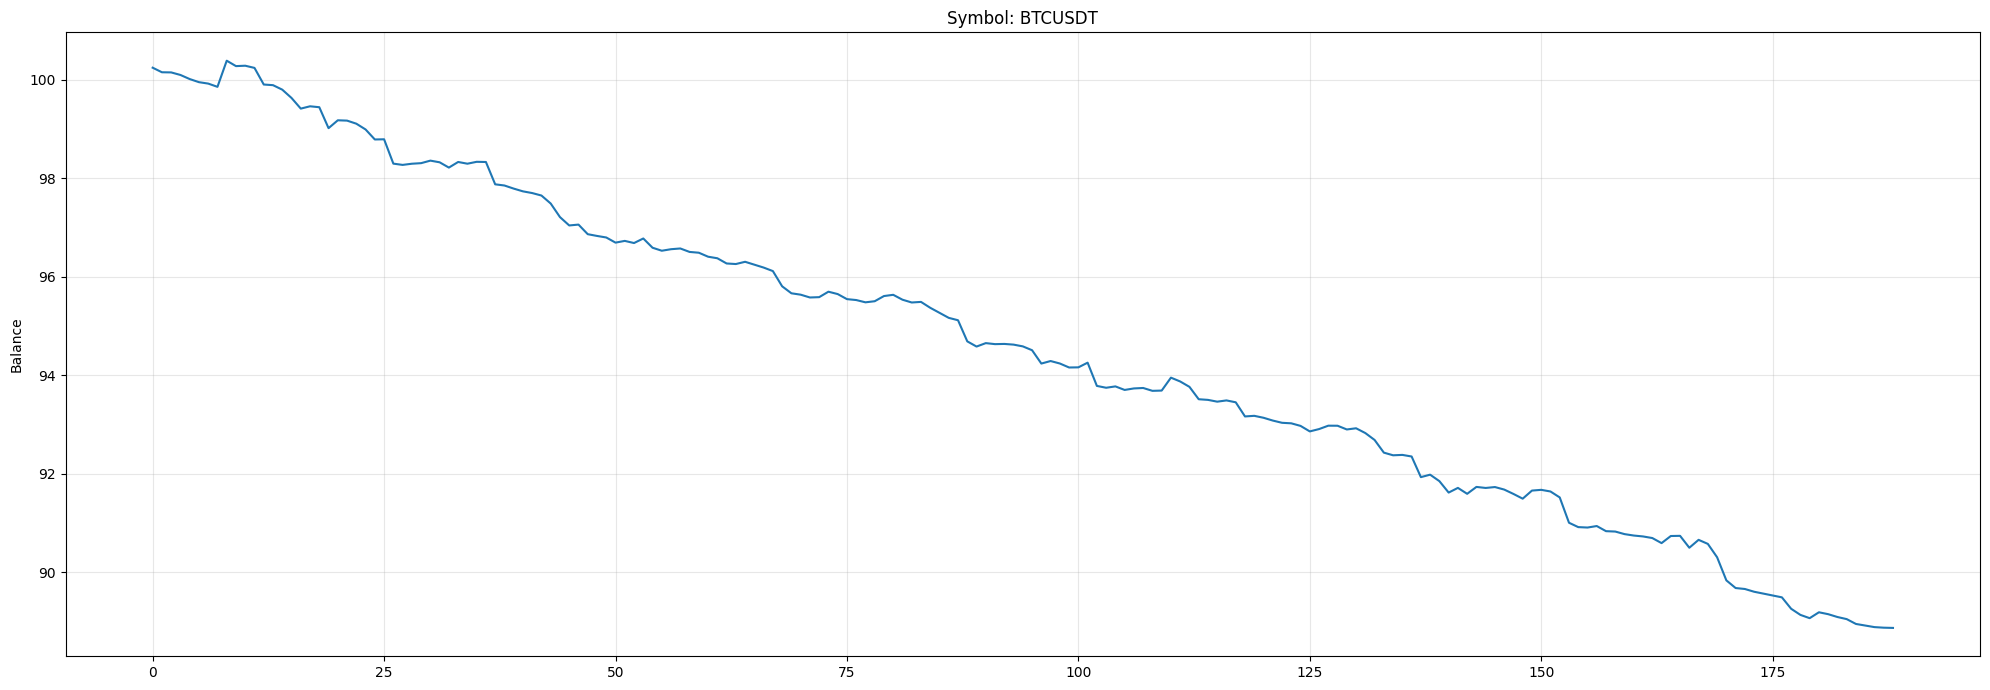

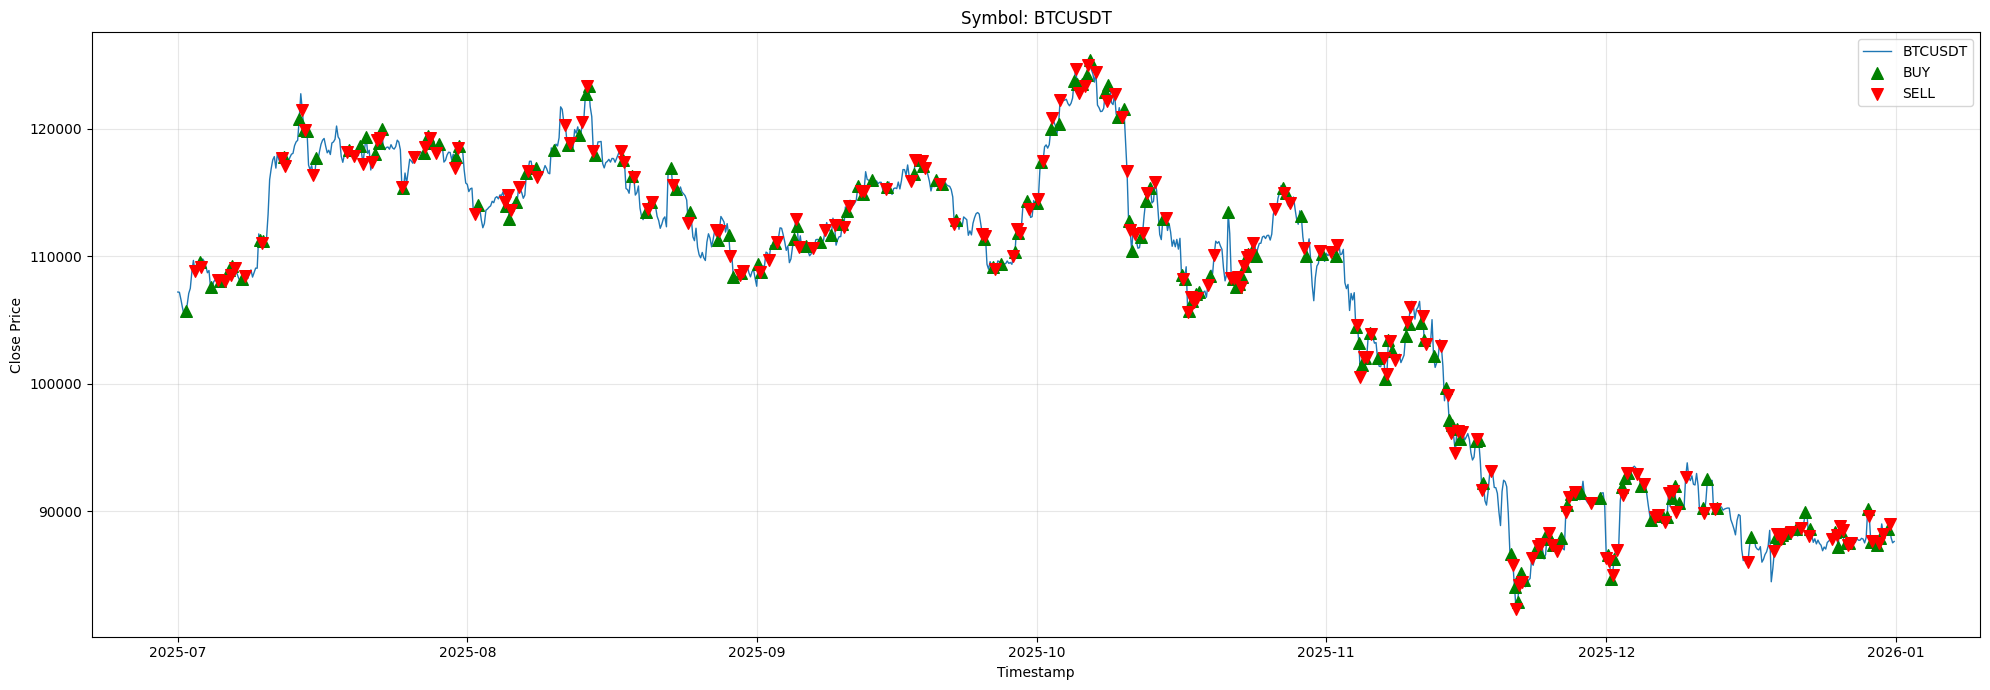

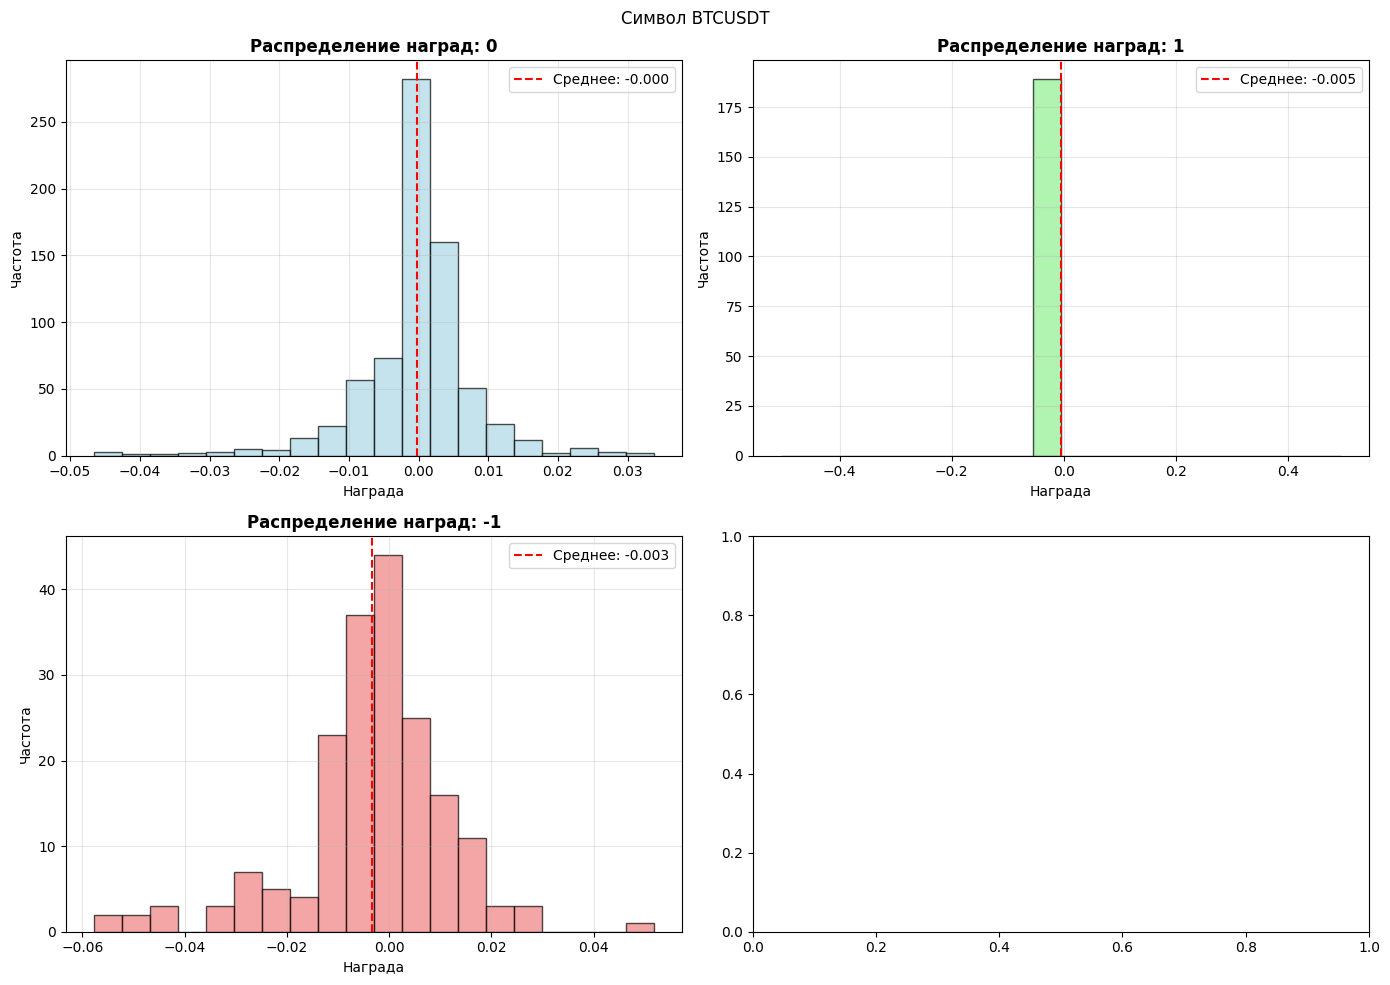

СТАТИСТИКА ПО ДЕЙСТВИЯМ:

0:
  Количество: 726
  Среднее: -0.0002
  Медиана: 0.0001
  Стандартное отклонение: 0.0083
  Минимум: -0.0466
  Максимум: 0.0338
  25-й перцентиль: -0.0026
  75-й перцентиль: 0.0033

1:
  Количество: 189
  Среднее: -0.0050
  Медиана: -0.0050
  Стандартное отклонение: 0.0000
  Минимум: -0.0050
  Максимум: -0.0050
  25-й перцентиль: -0.0050
  75-й перцентиль: -0.0050

-1:
  Количество: 189
  Среднее: -0.0033
  Медиана: -0.0020
  Стандартное отклонение: 0.0151
  Минимум: -0.0578
  Максимум: 0.0518
  25-й перцентиль: -0.0088
  75-й перцентиль: 0.0036


In [287]:
backtesting.plots(mode_train=False, Actions_equity=True, Reward_stats=True)